#**Global Stability Analysis from MD Simulations**

# 1) Summary of Stability Metrics

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------
# Settings
# -------------------
T0_NS, T1_NS = 20.0, 60.0
BASE_DIR = Path(".")
REPLICA_LABELS = ["Rep 1", "Rep 2", "Rep 3"]

# -------------------
# Define your 4 systems here
# -------------------
SYSTEMS = {
    "5FWJ_holo": {
        "base_dir": BASE_DIR,
        "metrics": {
            "Cα RMSD (nm)": {
                "files": [
                    "rmsd_jmjc_CA_holo_rep1.xvg",
                    "rmsd_jmjc_CA_holo_rep2.xvg",
                    "rmsd_jmjc_CA_holo_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "RMSD (nm)",
            },
            "Radius of gyration (Rg) (nm)": {
                "files": [
                    "rg_jmjc_holo_rep1.xvg",
                    "rg_jmjc_holo_rep2.xvg",
                    "rg_jmjc_holo_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "Rg (nm)",
            },
            "SASA (nm$^2$)": {
                "files": [
                    "sasa_total_holo_rep1.xvg",
                    "sasa_total_holo_rep2.xvg",
                    "sasa_total_holo_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "SASA (nm$^2$)",
            },
        },
    },

    "5FWJ_apo": {
        "base_dir": BASE_DIR,
        "metrics": {
            "Cα RMSD (nm)": {
                "files": [
                    "rmsd_jmjc_CA_apo_rep1.xvg",
                    "rmsd_jmjc_CA_apo_rep2.xvg",
                    "rmsd_jmjc_CA_apo_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "RMSD (nm)",
            },
            "Radius of gyration (Rg) (nm)": {
                "files": [
                    "rg_jmjc_apo_rep1.xvg",
                    "rg_jmjc_apo_rep2.xvg",
                    "rg_jmjc_apo_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "Rg (nm)",
            },
            "SASA (nm$^2$)": {
                "files": [
                    "sasa_total_apo_rep1.xvg",
                    "sasa_total_apo_rep2.xvg",
                    "sasa_total_apo_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "SASA (nm$^2$)",
            },
        },
    },

    "PAF": {
        "base_dir": BASE_DIR,
        "metrics": {
            "Cα RMSD (nm)": {
                "files": [
                    "rmsd_jmjc_CA_PAF_rep1.xvg",
                    "rmsd_jmjc_CA_PAF_rep2.xvg",
                    "rmsd_jmjc_CA_PAF_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "RMSD (nm)",
            },
            "Radius of gyration (Rg) (nm)": {
                "files": [
                    "rg_jmjc_PAF_rep1.xvg",
                    "rg_jmjc_PAF_rep2.xvg",
                    "rg_jmjc_PAF_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "Rg (nm)",
            },
            "SASA (nm$^2$)": {
                "files": [
                    "sasa_total_PAF_rep1.xvg",
                    "sasa_total_PAF_rep2.xvg",
                    "sasa_total_PAF_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "SASA (nm$^2$)",
            },
        },
    },

    "CAF": {
        "base_dir": BASE_DIR,
        "metrics": {
            "Cα RMSD (nm)": {
                "files": [
                    "rmsd_jmjc_CA_CAF_rep1.xvg",
                    "rmsd_jmjc_CA_CAF_rep2.xvg",
                    "rmsd_jmjc_CA_CAF_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "RMSD (nm)",
            },
            "Radius of gyration (Rg) (nm)": {
                "files": [
                    "rg_jmjc_CAF_rep1.xvg",
                    "rg_jmjc_CAF_rep2.xvg",
                    "rg_jmjc_CAF_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "Rg (nm)",
            },
            "SASA (nm$^2$)": {
                "files": [
                    "sasa_total_CAF_rep1.xvg",
                    "sasa_total_CAF_rep2.xvg",
                    "sasa_total_CAF_rep3.xvg",
                ],
                "col": 1,
                "ylabel": "SASA (nm$^2$)",
            },
        },
    },
}

# -------------------
# Helpers
# -------------------
def read_xvg_columns(path: Path):
    data = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "@")):
                continue
            parts = s.split()
            try:
                data.append([float(x) for x in parts])
            except ValueError:
                continue
    if not data:
        raise ValueError(f"No numeric data found in {path}")
    return np.array(data, dtype=float)

def auto_to_ns(t):
    return t / 1000.0 if np.nanmax(t) > 200 else t

def window_stats(t_ns, y, t0=T0_NS, t1=T1_NS):
    mask = (t_ns >= t0) & (t_ns <= t1)
    if mask.sum() < 3:
        raise ValueError(f"Too few points in {t0}-{t1} ns window (found {mask.sum()}).")
    return float(np.mean(y[mask])), float(np.std(y[mask], ddof=1)), int(mask.sum())

def fmt_pm(mean_val, sd_val, decimals=3):
    return f"{mean_val:.{decimals}f} ± {sd_val:.{decimals}f}"

def per_rep_window_stats(system_base_dir, files3, col):
    rep_stats = []

    for rep_label, fname in zip(REPLICA_LABELS, files3):
        path = system_base_dir / fname
        if not path.exists():
            raise FileNotFoundError(f"Missing file for {rep_label}: {path}")

        arr = read_xvg_columns(path)
        if col >= arr.shape[1]:
            raise ValueError(f"{path} has {arr.shape[1]} columns; requested col={col}")

        t_ns = auto_to_ns(arr[:, 0])
        y = arr[:, col]

        mu, sd, n = window_stats(t_ns, y)

        rep_stats.append({
            "Replica": rep_label,
            "Mean": mu,
            "SD": sd,
            "Mean ± SD": fmt_pm(mu, sd),
            "Npoints in window": n,
            "t_first(ns)": float(t_ns[0]),
            "t_last(ns)": float(t_ns[-1]),
            "Source file": str(path.name),
        })

    rep_means = np.array([x["Mean"] for x in rep_stats], dtype=float)
    across_mu = float(rep_means.mean())
    across_sd = float(rep_means.std(ddof=1))

    return rep_stats, across_mu, across_sd

def plot_overlay(system_name, metric_name, cfg, system_base_dir):
    files3 = cfg["files"]
    col = int(cfg.get("col", 1))
    ylabel = cfg.get("ylabel", "Value")

    plt.figure(figsize=(7, 4))

    for rep_label, fname in zip(REPLICA_LABELS, files3):
        path = system_base_dir / fname
        arr = read_xvg_columns(path)
        t_ns = auto_to_ns(arr[:, 0])
        y = arr[:, col]
        plt.plot(t_ns, y, label=rep_label, linewidth=1.2)

    plt.axvspan(T0_NS, T1_NS, alpha=0.15)
    plt.title(f"{system_name} — {metric_name}")
    plt.xlabel("Time (ns)")
    plt.ylabel(ylabel)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# -------------------
# Build tables for all systems
# -------------------
all_summary_rows = []
all_debug_rows = []

for system_name, system_cfg in SYSTEMS.items():
    system_base_dir = system_cfg["base_dir"]
    metrics = system_cfg["metrics"]

    summary_rows = []
    debug_rows = []

    for metric_name, cfg in metrics.items():
        rep_stats, across_mu, across_sd = per_rep_window_stats(
            system_base_dir=system_base_dir,
            files3=cfg["files"],
            col=int(cfg.get("col", 1))
        )

        summary_row = {
            "System": system_name,
            "Metric": metric_name,
            "Rep 1 (20–60 ns, mean ± SD)": rep_stats[0]["Mean ± SD"],
            "Rep 2 (20–60 ns, mean ± SD)": rep_stats[1]["Mean ± SD"],
            "Rep 3 (20–60 ns, mean ± SD)": rep_stats[2]["Mean ± SD"],
            "Replica-average of means (mean ± SD)": fmt_pm(across_mu, across_sd),
        }
        summary_rows.append(summary_row)
        all_summary_rows.append(summary_row)

        for d in rep_stats:
            debug_row = {
                "System": system_name,
                "Metric": metric_name,
                **d
            }
            debug_rows.append(debug_row)
            all_debug_rows.append(debug_row)

    df_summary = pd.DataFrame(summary_rows)
    df_debug = pd.DataFrame(debug_rows)

    summary_csv = f"global_summary_{system_name}.csv"
    debug_csv = f"global_debug_{system_name}.csv"

    df_summary.to_csv(summary_csv, index=False)
    df_debug.to_csv(debug_csv, index=False)

    print(f"[Saved] {summary_csv}")
    print(f"[Saved] {debug_csv}")

    display(df_summary)
    display(df_debug)

# -------------------
# Combined CSVs for all systems
# -------------------
df_all_summary = pd.DataFrame(all_summary_rows)
df_all_debug = pd.DataFrame(all_debug_rows)

df_all_summary.to_csv("global_summary_all_systems.csv", index=False)
df_all_debug.to_csv("global_debug_all_systems.csv", index=False)

print("[Saved] global_summary_all_systems.csv")
print("[Saved] global_debug_all_systems.csv")

display(df_all_summary)
display(df_all_debug)

[Saved] global_summary_5FWJ_holo.csv
[Saved] global_debug_5FWJ_holo.csv


,System,Metric,"Rep 1 (20–60 ns, mean ± SD)","Rep 2 (20–60 ns, mean ± SD)","Rep 3 (20–60 ns, mean ± SD)",Replica-average of means (mean ± SD)
0,5FWJ_holo,Cα RMSD (nm),0.164 ± 0.022,0.124 ± 0.026,0.134 ± 0.015,0.140 ± 0.021
1,5FWJ_holo,Radius of gyration (Rg) (nm),1.680 ± 0.014,1.656 ± 0.010,1.644 ± 0.008,1.660 ± 0.018
2,5FWJ_holo,SASA (nm$^2$),98.725 ± 2.751,96.930 ± 1.493,95.510 ± 1.636,97.055 ± 1.611


,System,Metric,Replica,Mean,SD,Mean ± SD,Npoints in window,t_first(ns),t_last(ns),Source file
0,5FWJ_holo,Cα RMSD (nm),Rep 1,0.163749,0.022458,0.164 ± 0.022,4000,0.0,60.000004,rmsd_jmjc_CA_holo_rep1.xvg
1,5FWJ_holo,Cα RMSD (nm),Rep 2,0.123690,0.026325,0.124 ± 0.026,4000,0.0,60.000004,rmsd_jmjc_CA_holo_rep2.xvg
2,5FWJ_holo,Cα RMSD (nm),Rep 3,0.133819,0.014540,0.134 ± 0.015,4000,0.0,60.000004,rmsd_jmjc_CA_holo_rep3.xvg
3,5FWJ_holo,Radius of gyration (Rg) (nm),Rep 1,1.679850,0.013966,1.680 ± 0.014,4001,0.0,60.000000,rg_jmjc_holo_rep1.xvg
4,5FWJ_holo,Radius of gyration (Rg) (nm),Rep 2,1.656380,0.009735,1.656 ± 0.010,4001,0.0,60.000000,rg_jmjc_holo_rep2.xvg
5,5FWJ_holo,Radius of gyration (Rg) (nm),Rep 3,1.643570,0.008439,1.644 ± 0.008,4001,0.0,60.000000,rg_jmjc_holo_rep3.xvg
6,5FWJ_holo,SASA (nm$^2$),Rep 1,98.725205,2.750646,98.725 ± 2.751,4001,0.0,60.000000,sasa_total_holo_rep1.xvg
7,5FWJ_holo,SASA (nm$^2$),Rep 2,96.930234,1.493227,96.930 ± 1.493,4001,0.0,60.000000,sasa_total_holo_rep2.xvg
8,5FWJ_holo,SASA (nm$^2$),Rep 3,95.510036,1.635588,95.510 ± 1.636,4001,0.0,60.000000,sasa_total_holo_rep3.xvg


[Saved] global_summary_5FWJ_apo.csv
[Saved] global_debug_5FWJ_apo.csv


,System,Metric,"Rep 1 (20–60 ns, mean ± SD)","Rep 2 (20–60 ns, mean ± SD)","Rep 3 (20–60 ns, mean ± SD)",Replica-average of means (mean ± SD)
0,5FWJ_apo,Cα RMSD (nm),0.143 ± 0.016,0.129 ± 0.012,0.203 ± 0.021,0.158 ± 0.040
1,5FWJ_apo,Radius of gyration (Rg) (nm),1.653 ± 0.012,1.646 ± 0.009,1.679 ± 0.011,1.660 ± 0.017
2,5FWJ_apo,SASA (nm$^2$),96.156 ± 1.498,94.850 ± 1.665,98.241 ± 1.380,96.416 ± 1.710


...

,System,Metric,"Rep 1 (20–60 ns, mean ± SD)","Rep 2 (20–60 ns, mean ± SD)","Rep 3 (20–60 ns, mean ± SD)",Replica-average of means (mean ± SD)
0,CAF,Cα RMSD (nm),0.117 ± 0.018,0.148 ± 0.011,0.148 ± 0.016,0.138 ± 0.018
1,CAF,Radius of gyration (Rg) (nm),1.697 ± 0.008,1.735 ± 0.007,1.701 ± 0.008,1.711 ± 0.021
2,CAF,SASA (nm$^2$),102.184 ± 1.397,106.067 ± 1.377,104.477 ± 1.269,104.243 ± 1.952


,System,Metric,Replica,Mean,SD,Mean ± SD,Npoints in window,t_first(ns),t_last(ns),Source file
0,CAF,Cα RMSD (nm),Rep 1,0.117117,0.018160,0.117 ± 0.018,4000,0.0,60.000004,rmsd_jmjc_CA_CAF_rep1.xvg
1,CAF,Cα RMSD (nm),Rep 2,0.147701,0.010573,0.148 ± 0.011,4000,0.0,60.000004,rmsd_jmjc_CA_CAF_rep2.xvg
2,CAF,Cα RMSD (nm),Rep 3,0.147969,0.015778,0.148 ± 0.016,4000,0.0,60.000004,rmsd_jmjc_CA_CAF_rep3.xvg
3,CAF,Radius of gyration (Rg) (nm),Rep 1,1.697324,0.008004,1.697 ± 0.008,4001,0.0,60.000000,rg_jmjc_CAF_rep1.xvg
4,CAF,Radius of gyration (Rg) (nm),Rep 2,1.735395,0.007358,1.735 ± 0.007,4001,0.0,60.000000,rg_jmjc_CAF_rep2.xvg
5,CAF,Radius of gyration (Rg) (nm),Rep 3,1.701396,0.007710,1.701 ± 0.008,4001,0.0,60.000000,rg_jmjc_CAF_rep3.xvg
6,CAF,SASA (nm$^2$),Rep 1,102.184233,1.396942,102.184 ± 1.397,4001,0.0,60.000000,sasa_total_CAF_rep1.xvg
7,CAF,SASA (nm$^2$),Rep 2,106.066912,1.377009,106.067 ± 1.377,4001,0.0,60.000000,sasa_total_CAF_rep2.xvg
8,CAF,SASA (nm$^2$),Rep 3,104.477109,1.269323,104.477 ± 1.269,4001,0.0,60.000000,sasa_total_CAF_rep3.xvg


[Saved] global_summary_all_systems.csv
[Saved] global_debug_all_systems.csv


,System,Metric,"Rep 1 (20–60 ns, mean ± SD)","Rep 2 (20–60 ns, mean ± SD)","Rep 3 (20–60 ns, mean ± SD)",Replica-average of means (mean ± SD)
0,5FWJ_holo,Cα RMSD (nm),0.164 ± 0.022,0.124 ± 0.026,0.134 ± 0.015,0.140 ± 0.021
1,5FWJ_holo,Radius of gyration (Rg) (nm),1.680 ± 0.014,1.656 ± 0.010,1.644 ± 0.008,1.660 ± 0.018
2,5FWJ_holo,SASA (nm$^2$),98.725 ± 2.751,96.930 ± 1.493,95.510 ± 1.636,97.055 ± 1.611
3,5FWJ_apo,Cα RMSD (nm),0.143 ± 0.016,0.129 ± 0.012,0.203 ± 0.021,0.158 ± 0.040
4,5FWJ_apo,Radius of gyration (Rg) (nm),1.653 ± 0.012,1.646 ± 0.009,1.679 ± 0.011,1.660 ± 0.017
5,5FWJ_apo,SASA (nm$^2$),96.156 ± 1.498,94.850 ± 1.665,98.241 ± 1.380,96.416 ± 1.710
6,PAF,Cα RMSD (nm),0.170 ± 0.018,0.110 ± 0.016,0.122 ± 0.014,0.134 ± 0.032
7,PAF,Radius of gyration (Rg) (nm),1.731 ± 0.008,1.696 ± 0.008,1.716 ± 0.008,1.714 ± 0.018
8,PAF,SASA (nm$^2$),106.000 ± 1.202,103.015 ± 1.537,104.459 ± 1.333,104.491 ± 1.493
9,CAF,Cα RMSD (nm),0.117 ± 0.018,0.148 ± 0.011,0.148 ± 0.016,0.138 ± 0.018


,System,Metric,Replica,Mean,SD,Mean ± SD,Npoints in window,t_first(ns),t_last(ns),Source file
0,5FWJ_holo,Cα RMSD (nm),Rep 1,0.163749,0.022458,0.164 ± 0.022,4000,0.0,60.000004,rmsd_jmjc_CA_holo_rep1.xvg
1,5FWJ_holo,Cα RMSD (nm),Rep 2,0.123690,0.026325,0.124 ± 0.026,4000,0.0,60.000004,rmsd_jmjc_CA_holo_rep2.xvg
2,5FWJ_holo,Cα RMSD (nm),Rep 3,0.133819,0.014540,0.134 ± 0.015,4000,0.0,60.000004,rmsd_jmjc_CA_holo_rep3.xvg
3,5FWJ_holo,Radius of gyration (Rg) (nm),Rep 1,1.679850,0.013966,1.680 ± 0.014,4001,0.0,60.000000,rg_jmjc_holo_rep1.xvg
4,5FWJ_holo,Radius of gyration (Rg) (nm),Rep 2,1.656380,0.009735,1.656 ± 0.010,4001,0.0,60.000000,rg_jmjc_holo_rep2.xvg
5,5FWJ_holo,Radius of gyration (Rg) (nm),Rep 3,1.643570,0.008439,1.644 ± 0.008,4001,0.0,60.000000,rg_jmjc_holo_rep3.xvg
6,5FWJ_holo,SASA (nm$^2$),Rep 1,98.725205,2.750646,98.725 ± 2.751,4001,0.0,60.000000,sasa_total_holo_rep1.xvg
7,5FWJ_holo,SASA (nm$^2$),Rep 2,96.930234,1.493227,96.930 ± 1.493,4001,0.0,60.000000,sasa_total_holo_rep2.xvg
8,5FWJ_holo,SASA (nm$^2$),Rep 3,95.510036,1.635588,95.510 ± 1.636,4001,0.0,60.000000,sasa_total_holo_rep3.xvg
9,5FWJ_apo,Cα RMSD (nm),Rep 1,0.142530,0.016184,0.143 ± 0.016,4000,0.0,60.000004,rmsd_jmjc_CA_apo_rep1.xvg


# 2) Time-Series Plots

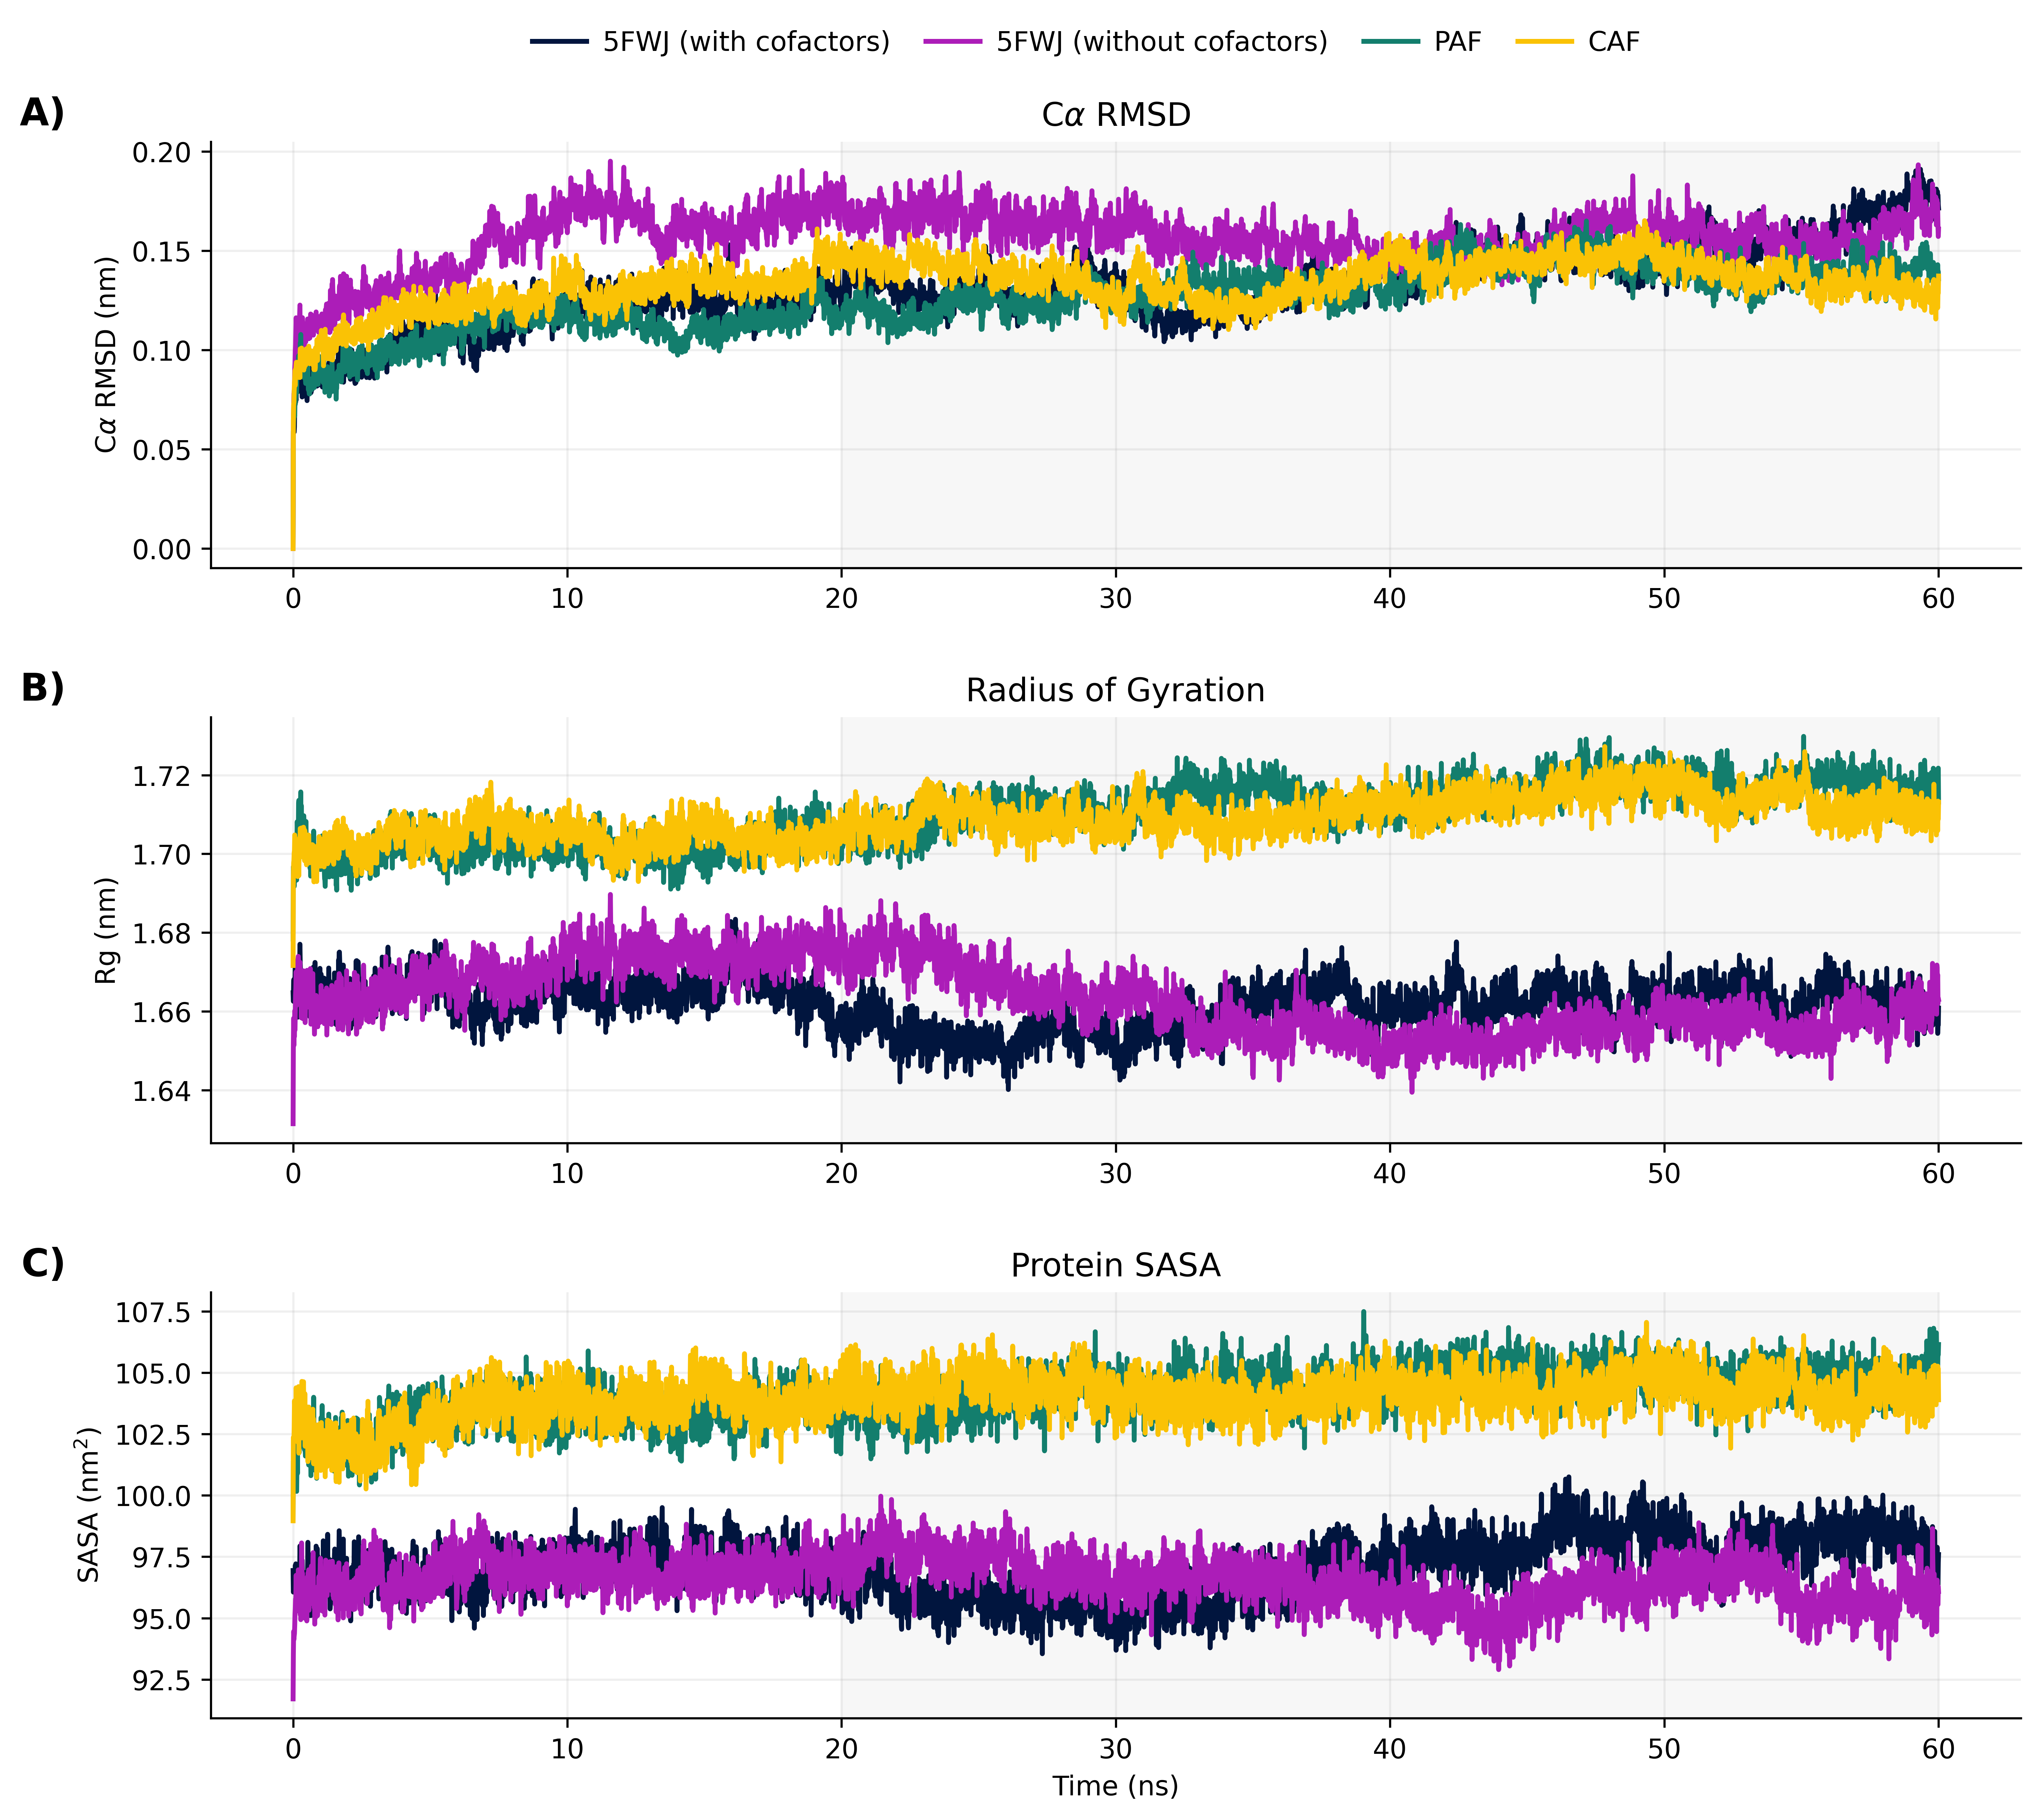

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# =========================
# Settings
# =========================
BASE_DIR = Path(".")
prod_start = 20  # production start (ns)

# =========================
# Colors / labels
# =========================
xkcd = mcolors.XKCD_COLORS

COND_COLOR = {
    "5FWJ_holo": xkcd["xkcd:navy"],
    "5FWJ_apo":  xkcd["xkcd:barney"],
    "PAF":       xkcd["xkcd:blue green"],
    "CAF":       xkcd["xkcd:goldenrod"],
}

LABEL = {
    "5FWJ_holo": "5FWJ (with cofactors)",
    "5FWJ_apo":  "5FWJ (without cofactors)",
    "PAF":       "PAF",
    "CAF":       "CAF",
}

SYSTEMS = {
    "5FWJ_holo": {
        "base_dir": BASE_DIR,
        "metrics": {
            "rmsd": [
                "rmsd_jmjc_CA_holo_rep1.xvg",
                "rmsd_jmjc_CA_holo_rep2.xvg",
                "rmsd_jmjc_CA_holo_rep3.xvg",
            ],
            "rg": [
                "rg_jmjc_holo_rep1.xvg",
                "rg_jmjc_holo_rep2.xvg",
                "rg_jmjc_holo_rep3.xvg",
            ],
            "sasa": [
                "sasa_total_holo_rep1.xvg",
                "sasa_total_holo_rep2.xvg",
                "sasa_total_holo_rep3.xvg",
            ],
        },
    },
    "5FWJ_apo": {
        "base_dir": BASE_DIR,
        "metrics": {
            "rmsd": [
                "rmsd_jmjc_CA_apo_rep1.xvg",
                "rmsd_jmjc_CA_apo_rep2.xvg",
                "rmsd_jmjc_CA_apo_rep3.xvg",
            ],
            "rg": [
                "rg_jmjc_apo_rep1.xvg",
                "rg_jmjc_apo_rep2.xvg",
                "rg_jmjc_apo_rep3.xvg",
            ],
            "sasa": [
                "sasa_total_apo_rep1.xvg",
                "sasa_total_apo_rep2.xvg",
                "sasa_total_apo_rep3.xvg",
            ],
        },
    },
    "PAF": {
        "base_dir": BASE_DIR,
        "metrics": {
            "rmsd": [
                "rmsd_jmjc_CA_PAF_rep1.xvg",
                "rmsd_jmjc_CA_PAF_rep2.xvg",
                "rmsd_jmjc_CA_PAF_rep3.xvg",
            ],
            "rg": [
                "rg_jmjc_PAF_rep1.xvg",
                "rg_jmjc_PAF_rep2.xvg",
                "rg_jmjc_PAF_rep3.xvg",
            ],
            "sasa": [
                "sasa_total_PAF_rep1.xvg",
                "sasa_total_PAF_rep2.xvg",
                "sasa_total_PAF_rep3.xvg",
            ],
        },
    },
    "CAF": {
        "base_dir": BASE_DIR,
        "metrics": {
            "rmsd": [
                "rmsd_jmjc_CA_CAF_rep1.xvg",
                "rmsd_jmjc_CA_CAF_rep2.xvg",
                "rmsd_jmjc_CA_CAF_rep3.xvg",
            ],
            "rg": [
                "rg_jmjc_CAF_rep1.xvg",
                "rg_jmjc_CAF_rep2.xvg",
                "rg_jmjc_CAF_rep3.xvg",
            ],
            "sasa": [
                "sasa_total_CAF_rep1.xvg",
                "sasa_total_CAF_rep2.xvg",
                "sasa_total_CAF_rep3.xvg",
            ],
        },
    },
}

def read_xvg_columns(path: Path):
    data = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "@")):
                continue
            parts = s.split()
            try:
                data.append([float(x) for x in parts])
            except ValueError:
                continue
    if not data:
        raise ValueError(f"No numeric data found in {path}")
    return np.array(data, dtype=float)

def auto_to_ns(t):
    return t / 1000.0 if np.nanmax(t) > 200 else t

def load_replicates(files, col=1, base_dir=BASE_DIR):
    xs, ys = [], []
    for fname in files:
        path = base_dir / fname
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path}")
        arr = read_xvg_columns(path)
        if col >= arr.shape[1]:
            raise ValueError(f"{path} has {arr.shape[1]} columns; requested col={col}")
        t_ns = auto_to_ns(arr[:, 0])
        y = arr[:, col]
        xs.append(t_ns)
        ys.append(y)
    return xs, ys

def build_mean_trace(files, col=1, base_dir=BASE_DIR):
    xs, ys = load_replicates(files, col=col, base_dir=base_dir)

    lengths = [len(x) for x in xs]
    if len(set(lengths)) != 1:
        raise ValueError(f"Replicate time arrays have different lengths: {lengths}")

    x_ref = xs[0]
    for i, x in enumerate(xs[1:], start=2):
        if not np.allclose(x_ref, x):
            raise ValueError(f"Time grid mismatch between replicate 1 and replicate {i}")

    y_stack = np.vstack(ys)
    y_mean = np.mean(y_stack, axis=0)
    y_sd = np.std(y_stack, axis=0, ddof=1)
    return x_ref, y_mean, y_sd

def build_metric_dict(metric_key):
    out = {}
    for system_name, cfg in SYSTEMS.items():
        x, y_mean, y_sd = build_mean_trace(
            cfg["metrics"][metric_key],
            col=1,
            base_dir=cfg["base_dir"]
        )
        out[system_name] = (x, y_mean, y_sd)
    return out

def plot_metric_onepanel(ax, metric_dict, y_label, title, show_sd=False):
    for system_name, (x, y_mean, y_sd) in metric_dict.items():
        ax.plot(
            x,
            y_mean,
            label=LABEL[system_name],
            linewidth=1.8,
            color=COND_COLOR[system_name],
        )
        if show_sd:
            ax.fill_between(
                x,
                y_mean - y_sd,
                y_mean + y_sd,
                color=COND_COLOR[system_name],
                alpha=0.18,
            )
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=12)

mean_rmsd = build_metric_dict("rmsd")
mean_rg   = build_metric_dict("rg")
mean_sasa = build_metric_dict("sasa")

fig, ax = plt.subplots(3, 1, figsize=(12, 10), dpi=300, sharex=True)

plot_metric_onepanel(ax[0], mean_rmsd, y_label=r"C$\alpha$ RMSD (nm)", title=r"C$\alpha$ RMSD", show_sd=False)
plot_metric_onepanel(ax[1], mean_rg,   y_label="Rg (nm)",               title="Radius of Gyration", show_sd=False)
plot_metric_onepanel(ax[2], mean_sasa, y_label=r"SASA (nm$^2$)",        title="Protein SASA", show_sd=False)

for a in ax:
    a.tick_params(axis="x", which="both", labelbottom=True)

ax[0].set_xlabel("")
ax[1].set_xlabel("")
ax[2].set_xlabel("Time (ns)")

for a in ax:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.tick_params(direction="out")
    a.grid(True, alpha=0.20)

for a, letter in zip(ax, ["A", "B", "C"]):
    a.text(-0.08, 1.02, f"{letter})",
           transform=a.transAxes,
           ha="right", va="bottom",
           fontsize=14, fontweight="bold")

for a in ax[1:]:
    leg = a.get_legend()
    if leg is not None:
        leg.remove()

x_end_candidates = []
for system_name in SYSTEMS:
    if system_name in mean_rmsd:
        x_end_candidates.append(mean_rmsd[system_name][0][-1])
x_end = max(x_end_candidates) if x_end_candidates else 60

for a in ax:
    a.axvspan(prod_start, x_end, color="0.5", alpha=0.06, linewidth=0)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 0.99),
           ncol=4,
           frameon=False,
           columnspacing=1.3,
           handletextpad=0.6)

fig.subplots_adjust(top=0.92, hspace=0.35)
plt.show()

#**RMSF Protein Plot**

[INFO] DATA_DIR = /content
[INFO] DATA_DIR exists: True
[INFO] Found 48 .xvg files in /content:
   - rg_jmjc_CAF_rep1.xvg
   - rg_jmjc_CAF_rep2.xvg
   - rg_jmjc_CAF_rep3.xvg
   - rg_jmjc_PAF_rep1.xvg
   - rg_jmjc_PAF_rep2.xvg
   - rg_jmjc_PAF_rep3.xvg
   - rg_jmjc_apo_rep1.xvg
   - rg_jmjc_apo_rep2.xvg
   - rg_jmjc_apo_rep3.xvg
   - rg_jmjc_holo_rep1.xvg
   - rg_jmjc_holo_rep2.xvg
   - rg_jmjc_holo_rep3.xvg
   - rmsd_jmjc_CA_CAF_rep1.xvg
   - rmsd_jmjc_CA_CAF_rep2.xvg
   - rmsd_jmjc_CA_CAF_rep3.xvg
   - rmsd_jmjc_CA_PAF_rep1.xvg
   - rmsd_jmjc_CA_PAF_rep2.xvg
   - rmsd_jmjc_CA_PAF_rep3.xvg
   - rmsd_jmjc_CA_apo_rep1.xvg
   - rmsd_jmjc_CA_apo_rep2.xvg
   - rmsd_jmjc_CA_apo_rep3.xvg
   - rmsd_jmjc_CA_holo_rep1.xvg
   - rmsd_jmjc_CA_holo_rep2.xvg
   - rmsd_jmjc_CA_holo_rep3.xvg
   - rmsf_jmjc_CA_CAF_rep1.xvg
   - rmsf_jmjc_CA_CAF_rep2.xvg
   - rmsf_jmjc_CA_CAF_rep3.xvg
   - rmsf_jmjc_CA_PAF_rep1.xvg
   - rmsf_jmjc_CA_PAF_rep2.xvg
   - rmsf_jmjc_CA_PAF_rep3.xvg
   - rmsf_jmjc_CA_apo_rep1.x

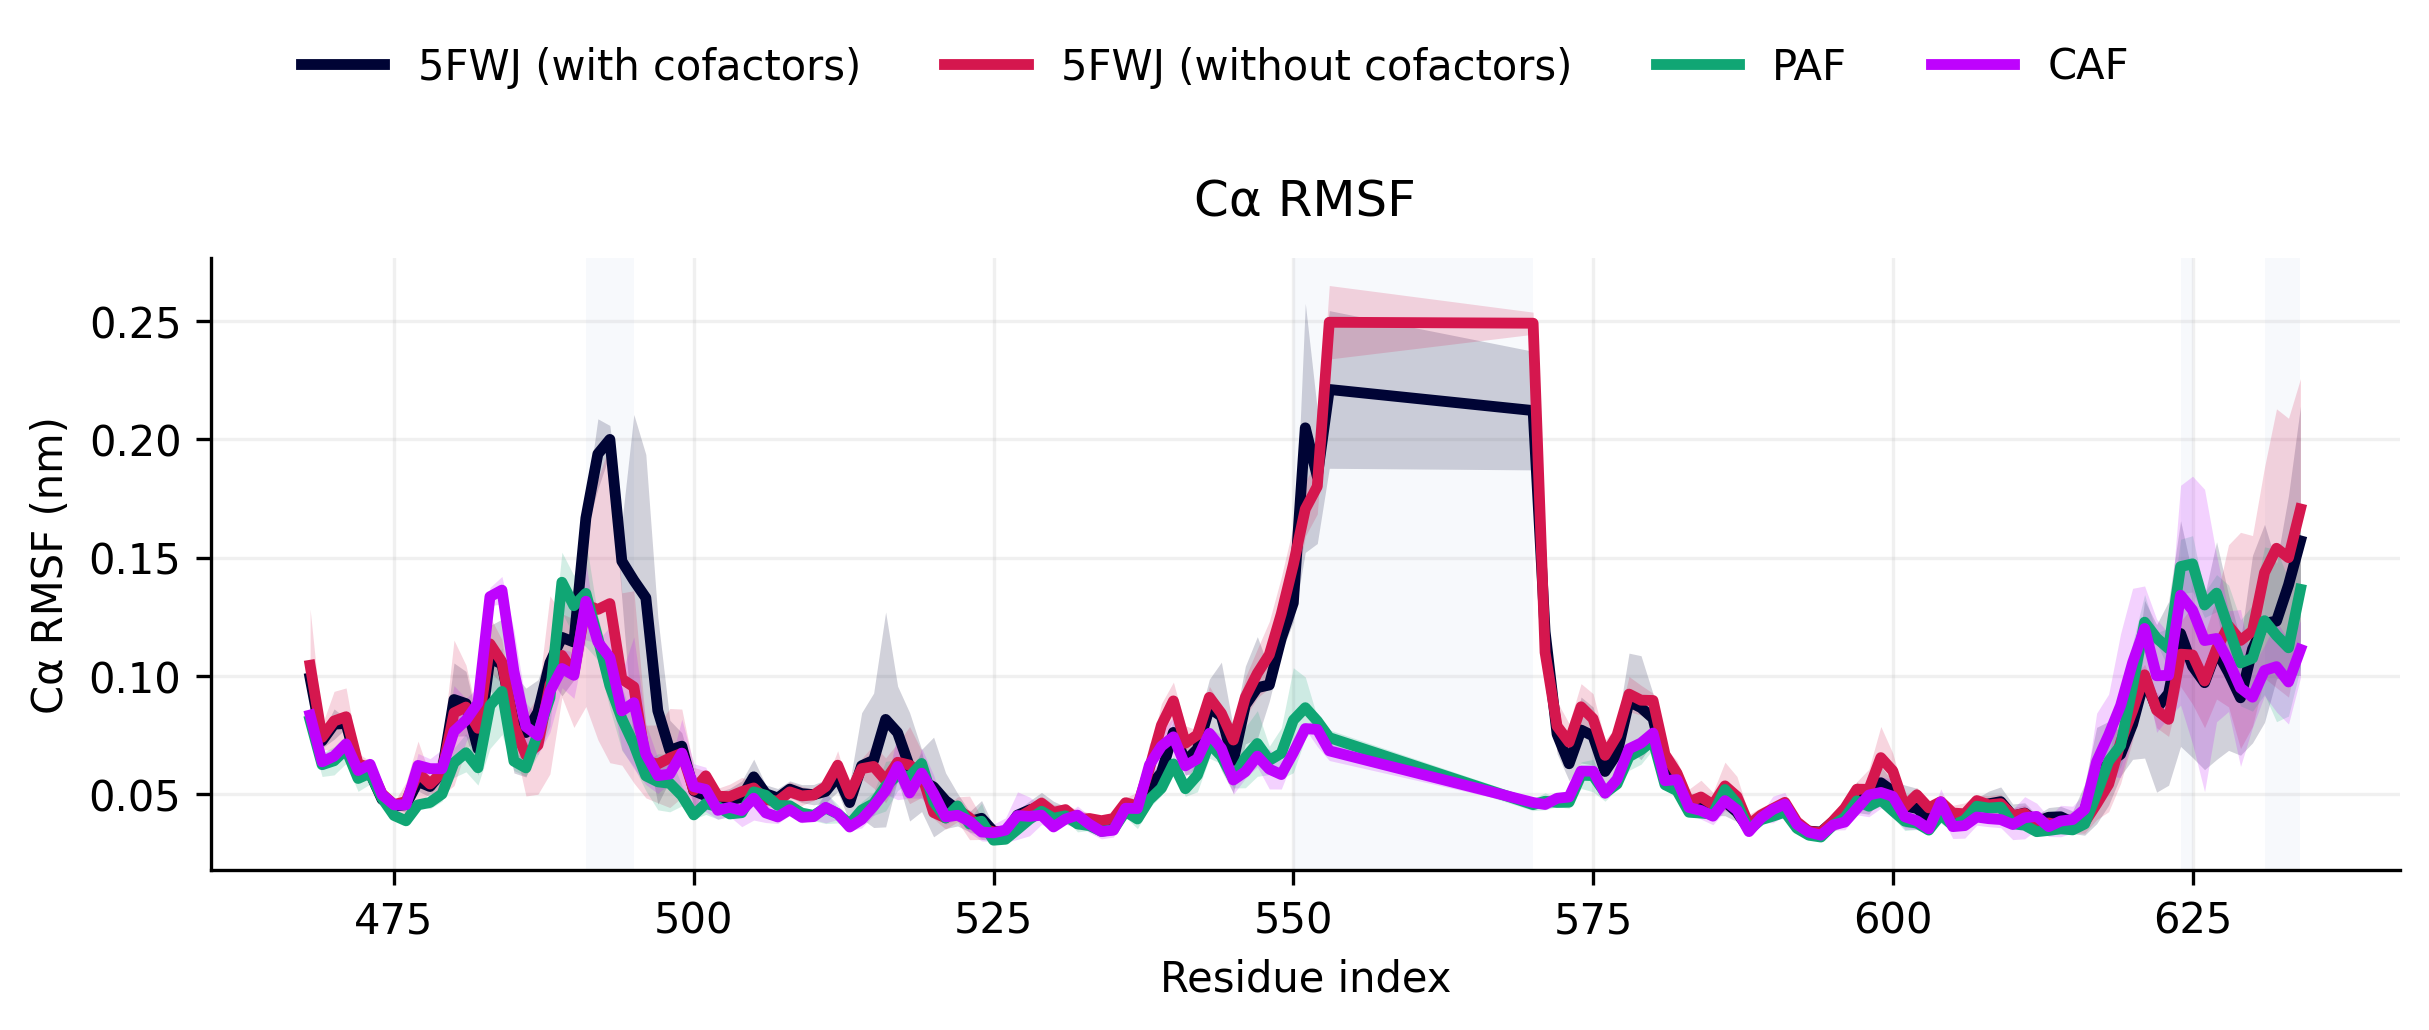

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# =========================
# SETTINGS
# =========================
DATA_DIR = Path("/content")

GROUPS = {
    "5FWJ (with cofactors)"    : "rmsf_jmjc_CA_holo_rep",
    "5FWJ (without cofactors)" : "rmsf_jmjc_CA_apo_rep",
    "PAF"                      : "rmsf_jmjc_CA_PAF_rep",
    "CAF"                      : "rmsf_jmjc_CA_CAF_rep",
}

models = [
    "5FWJ (with cofactors)",
    "5FWJ (without cofactors)",
    "PAF",
    "CAF",
]

xkcd = mcolors.XKCD_COLORS
COL = {
    "5FWJ (with cofactors)"    : xkcd["xkcd:dark navy"],
    "5FWJ (without cofactors)" : xkcd["xkcd:lipstick"],
    "PAF"                      : xkcd["xkcd:bluish green"],
    "CAF"                      : xkcd["xkcd:bright purple"],
}

HILITE = xkcd["xkcd:light blue grey"]
SHADE_ALPHA = 0.10

PCTL = 90
MIN_LEN = 2
GAP = 1

LW = 2.6
BAND_ALPHA = 0.18
TITLE_PAD = 10

OUT_PNG = "RMSF_4models_figure6.png"
OUT_PDF = "RMSF_4models_figure6.pdf"

# =========================
# HELPERS
# =========================
def read_xvg_2col(path):
    x, y = [], []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("@", "#")):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                x.append(float(parts[0]))
                y.append(float(parts[1]))
            except ValueError:
                continue
    if len(x) == 0:
        raise ValueError(f"No numeric 2-column data found in {path}")
    return np.array(x, dtype=float), np.array(y, dtype=float)

def aggregate_reps(paths):
    xs, ys = [], []
    for p in paths:
        x, y = read_xvg_2col(p)
        xs.append(x)
        ys.append(y)

    common = set(xs[0])
    for x in xs[1:]:
        common = common.intersection(set(x))
    common = np.array(sorted(common), dtype=float)

    if len(common) == 0:
        raise ValueError("No common residue indices across replicas.")

    Y = []
    for x, y in zip(xs, ys):
        mp = {xi: yi for xi, yi in zip(x, y)}
        Y.append([mp[c] for c in common])
    Y = np.array(Y, dtype=float)

    mean = Y.mean(axis=0)
    sd = Y.std(axis=0, ddof=1) if Y.shape[0] > 1 else np.zeros_like(mean)

    return common, mean, sd, Y.shape[0]

def style_axes(ax):
    ax.grid(True, which="major", alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def plot_mean_sd(ax, x, y_mean, y_sd, label, color, lw=LW, band_alpha=BAND_ALPHA):
    ax.plot(x, y_mean, color=color, lw=lw, label=label, zorder=3)
    if y_sd is not None:
        ax.fill_between(
            x, y_mean - y_sd, y_mean + y_sd,
            color=color, alpha=band_alpha, linewidth=0, zorder=2
        )

def make_peak_blocks(x, y, threshold, min_len=2, gap=1):
    x = np.asarray(x).astype(int)
    y = np.asarray(y)
    idx = np.where(y >= threshold)[0]
    if len(idx) == 0:
        return []

    blocks = []
    start = idx[0]
    prev = idx[0]

    for i in idx[1:]:
        if (i - prev) <= (gap + 1):
            prev = i
        else:
            if (prev - start + 1) >= min_len:
                blocks.append((x[start], x[prev]))
            start = i
            prev = i

    if (prev - start + 1) >= min_len:
        blocks.append((x[start], x[prev]))

    return blocks

def get_common_residues(agg, present_models):
    common = set(agg[present_models[0]]["res"].astype(int))
    for m in present_models[1:]:
        common = common.intersection(set(agg[m]["res"].astype(int)))
    return np.array(sorted(common), dtype=int)

def reindex_to(res_common, res, arr):
    res = np.asarray(res).astype(int)
    mp = {int(r): float(v) for r, v in zip(res, arr)}
    return np.array([mp[r] for r in res_common], dtype=float)

# =========================
# DEBUG: check folder and files
# =========================
print("[INFO] DATA_DIR =", DATA_DIR.resolve())
print("[INFO] DATA_DIR exists:", DATA_DIR.exists())

if DATA_DIR.exists():
    all_xvg = sorted(DATA_DIR.glob("*.xvg"))
    print(f"[INFO] Found {len(all_xvg)} .xvg files in {DATA_DIR}:")
    for f in all_xvg:
        print("   -", f.name)

# =========================
# BUILD AGGREGATED RMSF DATA
# =========================
agg = {}

for label, prefix in GROUPS.items():
    files = sorted(DATA_DIR.glob(f"{prefix}*.xvg"))

    if len(files) == 0:
        print(f"[WARN] No files found for: {label} (pattern: {prefix}*.xvg)")
        continue

    print(f"[OK] {label}: {len(files)} files")
    for f in files:
        print("   -", f.name)

    res, mean, sd, nrep = aggregate_reps(files)

    agg[label] = {
        "res": res,
        "mean": mean,
        "sd": sd,
        "nrep": nrep,
        "files": [f.name for f in files],
    }

print("\n[OK] agg keys:", list(agg.keys()))

# =========================
# SANITY CHECK
# =========================
if len(agg) == 0:
    raise RuntimeError(
        "agg is empty. Check DATA_DIR. "
        "Try Path('sample data') or Path('sample_data') depending on your folder name."
    )

present = [m for m in models if m in agg]
if len(present) == 0:
    raise RuntimeError(f"None of these models are in agg: {models}\nagg keys: {list(agg.keys())}")

# =========================
# PEAK REGIONS
# =========================
common = get_common_residues(agg, present)

if len(common) == 0:
    raise RuntimeError("No common residue indices across the selected models.")

Y = np.vstack([reindex_to(common, agg[m]["res"], agg[m]["mean"]) for m in present])
y_ref = Y.max(axis=0)

thr = np.nanpercentile(y_ref, PCTL)
blocks = make_peak_blocks(common, y_ref, threshold=thr, min_len=MIN_LEN, gap=GAP)

print("[OK] common residues:", len(common), "range:", (common[0], common[-1]))
print("[OK] peak threshold:", float(thr), f"(percentile {PCTL})")
print("[OK] highlight blocks:", blocks)

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(8.2, 3.2), dpi=300)

for x0, x1 in blocks:
    ax.axvspan(x0, x1, facecolor=HILITE, alpha=SHADE_ALPHA, zorder=1, linewidth=0)

for m in models:
    if m not in agg:
        print(f"[WARN] missing: {m}")
        continue

    r = common
    mu = reindex_to(common, agg[m]["res"], agg[m]["mean"])
    sd = reindex_to(common, agg[m]["res"], agg[m]["sd"])

    plot_mean_sd(ax, r, mu, sd, m, COL[m])

ax.set_xlabel("Residue index")
ax.set_ylabel("Cα RMSF (nm)")
ax.set_title("Cα RMSF", pad=TITLE_PAD)
style_axes(ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.08))

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight")

print(f"[Saved] {OUT_PNG}")
print(f"[Saved] {OUT_PDF}")

plt.show()

#**Pocket Analysis**


# 1) Summary of Stability Metrics

In [ ]:
# === POCKET stability table from XVG (4 systems × 3 replicas) ===
import numpy as np
import pandas as pd
from pathlib import Path

# -------- settings --------
TIME_UNIT_IN_XVG = "ns"   # "ps" or "ns"
T0_NS, T1_NS = 20.0, 60.0

REPLICA_DIRS = {
    "Rep 1": Path("."),
    "Rep 2": Path("."),
    "Rep 3": Path("."),
}

SYSTEMS = ["5FWJ_holo", "5FWJ_apo", "PAF", "CAF"]

# -------- your pocket XVG files (grouped by system) --------
POCKET_METRICS = {
    "Pocket RMSD (nm)": {
        "files": {
            "5FWJ_holo": [
                "rmsd_pocket_CA_holo_rep1.xvg",
                "rmsd_pocket_CA_holo_rep2.xvg",
                "rmsd_pocket_CA_holo_rep3.xvg",
            ],
            "5FWJ_apo": [
                "rmsd_pocket_CA_apo_rep1.xvg",
                "rmsd_pocket_CA_apo_rep2.xvg",
                "rmsd_pocket_CA_apo_rep3.xvg",
            ],
            "PAF": [
                "rmsd_pocket_CA_PAF_rep1.xvg",
                "rmsd_pocket_CA_PAF_rep2.xvg",
                "rmsd_pocket_CA_PAF_rep3.xvg",
            ],
            "CAF": [
                "rmsd_pocket_CA_CAF_rep1.xvg",
                "rmsd_pocket_CA_CAF_rep2.xvg",
                "rmsd_pocket_CA_CAF_rep3.xvg",
            ],
        },
    },
    "Pocket Rg (nm)": {
        "files": {
            "5FWJ_holo": [
                "rg_pocket_holo_rep1.xvg",
                "rg_pocket_holo_rep2.xvg",
                "rg_pocket_holo_rep3.xvg",
            ],
            "5FWJ_apo": [
                "rg_pocket_apo_rep1.xvg",
                "rg_pocket_apo_rep2.xvg",
                "rg_pocket_apo_rep3.xvg",
            ],
            "PAF": [
                "rg_pocket_PAF_rep1.xvg",
                "rg_pocket_PAF_rep2.xvg",
                "rg_pocket_PAF_rep3.xvg",
            ],
            "CAF": [
                "rg_pocket_CAF_rep1.xvg",
                "rg_pocket_CAF_rep2.xvg",
                "rg_pocket_CAF_rep3.xvg",
            ],
        },
    },
    "Pocket SASA (nm^2)": {
        "files": {
            "5FWJ_holo": [
                "sasa_jmjc_and_pocket_holo_rep1.xvg",
                "sasa_jmjc_and_pocket_holo_rep2.xvg",
                "sasa_jmjc_and_pocket_holo_rep3.xvg",
            ],
            "5FWJ_apo": [
                "sasa_jmjc_and_pocket_apo_rep1.xvg",
                "sasa_jmjc_and_pocket_apo_rep2.xvg",
                "sasa_jmjc_and_pocket_apo_rep3.xvg",
            ],
            "PAF": [
                "sasa_jmjc_and_pocket_PAF_rep1.xvg",
                "sasa_jmjc_and_pocket_PAF_rep2.xvg",
                "sasa_jmjc_and_pocket_PAF_rep3.xvg",
            ],
            "CAF": [
                "sasa_jmjc_and_pocket_CAF_rep1.xvg",
                "sasa_jmjc_and_pocket_CAF_rep2.xvg",
                "sasa_jmjc_and_pocket_CAF_rep3.xvg",
            ],
        },
    },
}

# -------- helpers --------
def read_xvg_xy(path: Path):
    t, y = [], []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "@")):
                continue
            a = s.split()
            if len(a) >= 2:
                t.append(float(a[0]))
                y.append(float(a[1]))
    return np.array(t), np.array(y)

def to_ns(t):
    return t / 1000.0 if TIME_UNIT_IN_XVG.lower() == "ps" else t

def window_mean(t_ns, y, t0=T0_NS, t1=T1_NS):
    m = (t_ns >= t0) & (t_ns <= t1)
    if m.sum() < 3:
        raise ValueError(
            f"Too few points in {t0}-{t1} ns (found {m.sum()}). "
            f"Check TIME_UNIT_IN_XVG and whether your XVG time range covers 20–60 ns."
        )
    return float(np.mean(y[m]))

def summarize_metric(files3):
    rep_means = []
    for (rep_label, rep_dir), fname in zip(REPLICA_DIRS.items(), files3):
        p = rep_dir / fname
        if not p.exists():
            raise FileNotFoundError(f"Missing file for {rep_label}: {p}")
        t, y = read_xvg_xy(p)
        rep_means.append(window_mean(to_ns(t), y))
    rep_means = np.array(rep_means, dtype=float)
    return rep_means, rep_means.mean(), rep_means.std(ddof=1)

# -------- build pocket table --------
rows = []
for metric_name, cfg in POCKET_METRICS.items():
    for system in SYSTEMS:
        files3 = cfg["files"][system]
        rep_means, mu, sd = summarize_metric(files3)

        rows.append({
            "System": system,
            "Metric": metric_name,
            "Rep 1 (20–60 ns mean)": rep_means[0],
            "Rep 2 (20–60 ns mean)": rep_means[1],
            "Rep 3 (20–60 ns mean)": rep_means[2],
            "Replica-avg (mean ± SD)": f"{mu:.3f} ± {sd:.3f}",
        })

df_pocket = pd.DataFrame(rows)
display(df_pocket)

# Optional:
for system in SYSTEMS:
    df_sys = df_pocket[df_pocket["System"] == system].copy()
    df_sys.to_csv(f"Table_Pocket_Stability_20-60ns_{system}.csv", index=False)

,System,Metric,Rep 1 (20–60 ns mean),Rep 2 (20–60 ns mean),Rep 3 (20–60 ns mean),Replica-avg (mean ± SD)
0,5FWJ_holo,Pocket RMSD (nm),0.144727,0.081245,0.078689,0.102 ± 0.037
1,5FWJ_apo,Pocket RMSD (nm),0.128355,0.128207,0.148003,0.135 ± 0.011
2,PAF,Pocket RMSD (nm),0.083592,0.081038,0.075872,0.080 ± 0.004
3,CAF,Pocket RMSD (nm),0.107816,0.097228,0.089792,0.098 ± 0.009
4,5FWJ_holo,Pocket Rg (nm),0.976839,0.950053,0.940276,0.956 ± 0.019
5,5FWJ_apo,Pocket Rg (nm),0.944199,0.928745,0.945141,0.939 ± 0.009
6,PAF,Pocket Rg (nm),0.938416,0.925112,0.927085,0.930 ± 0.007
7,CAF,Pocket Rg (nm),0.930980,0.955983,0.931546,0.940 ± 0.014
8,5FWJ_holo,Pocket SASA (nm^2),98.725205,96.930234,95.510036,97.055 ± 1.611
9,5FWJ_apo,Pocket SASA (nm^2),96.155684,94.849939,98.241062,96.416 ± 1.710


#02) Time-series plots

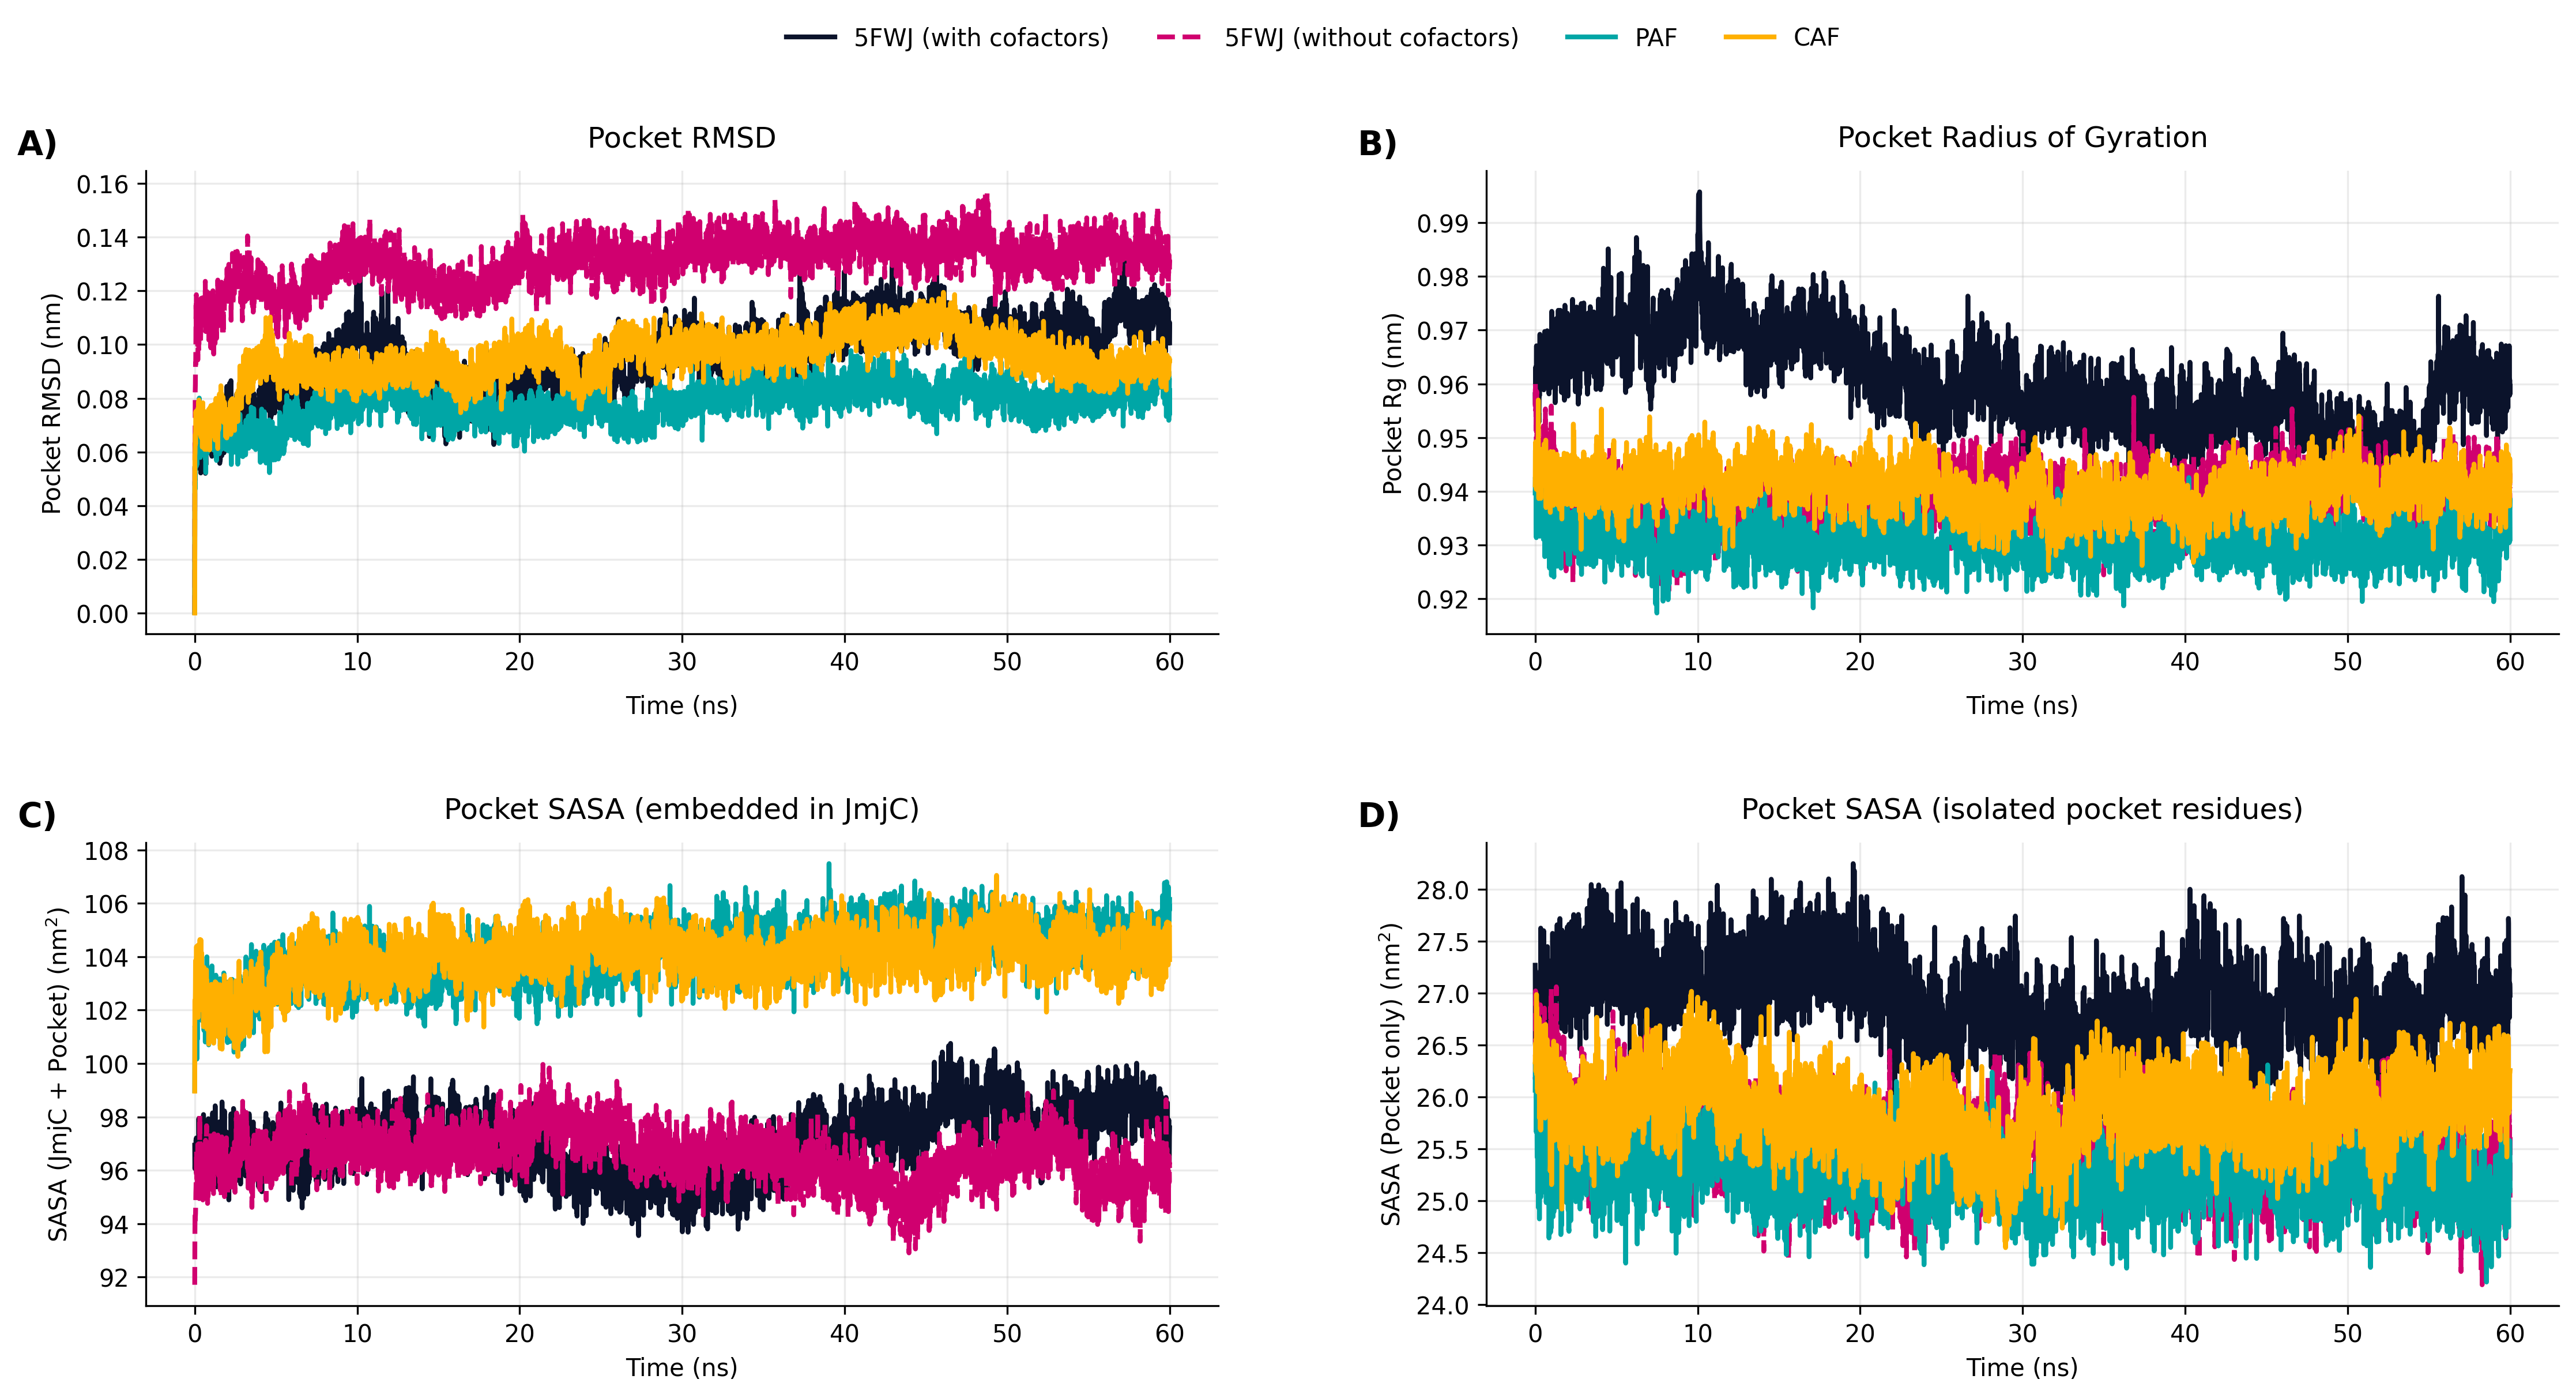

In [ ]:
import matplotlib.pyplot as plt

# =========================
# Plot settings
# =========================
ALL_CONDS = ("5FWJ_holo", "5FWJ_apo", "PAF", "CAF")
LEGEND_BOX = False

MODEL_COLOR = {
    "5FWJ_holo": "#0B132B",
    "5FWJ_apo":  "#D0006F",
    "PAF":       "#00A6A6",
    "CAF":       "#FFB000",
}

MODEL_LS = {
    "5FWJ_holo": "-",
    "5FWJ_apo":  "--",
    "PAF":       "-",
    "CAF":       "-",
}

LABEL = {
    "5FWJ_holo": "5FWJ (with cofactors)",
    "5FWJ_apo":  "5FWJ (without cofactors)",
    "PAF":       "PAF",
    "CAF":       "CAF",
}

METRIC_LABEL = {
    "rmsd_pocket_CA": "Pocket RMSD (nm)",
    "rg_pocket": "Pocket Rg (nm)",
    "sasa_jmjc_and_pocket": r"SASA (JmjC + Pocket) (nm$^2$)",
    "sasa_Pocketonly": r"SASA (Pocket only) (nm$^2$)",
}

METRIC_TITLE = {
    "rmsd_pocket_CA": "Pocket RMSD",
    "rg_pocket": "Pocket Radius of Gyration",
    "sasa_jmjc_and_pocket": "Pocket SASA (embedded in JmjC)",
    "sasa_Pocketonly": "Pocket SASA (isolated pocket residues)",
}

def plot_metric_onepanel_from_df(ax, df, metric, conds, y_label, title, x_scale=1.0, show_sd=False):
    for cond in conds:
        sub = df[(df["cond"] == cond) & (df["metric"] == metric)].copy()
        if sub.empty:
            print(f"[WARN] No data for cond={cond}, metric={metric}")
            continue

        sub = sub.sort_values("time")
        x = sub["time"].to_numpy(dtype=float) * x_scale
        y = sub["mean"].to_numpy(dtype=float)

        ax.plot(
            x, y,
            color=MODEL_COLOR[cond],
            linestyle=MODEL_LS[cond],
            linewidth=2.0,
            label=LABEL[cond]
        )

        if show_sd:
            sd = sub["sd"].to_numpy(dtype=float)
            ax.fill_between(
                x, y - sd, y + sd,
                color=MODEL_COLOR[cond],
                alpha=0.18,
                linewidth=0
            )

    ax.set_ylabel(y_label)
    ax.set_title(title, pad=10)

fig, axes = plt.subplots(2, 2, figsize=(18, 8), dpi=300, sharex=True)

axA, axB = axes[0, 0], axes[0, 1]
axC, axD = axes[1, 0], axes[1, 1]

plot_metric_onepanel_from_df(axA, all_df, "rmsd_pocket_CA", ALL_CONDS, METRIC_LABEL["rmsd_pocket_CA"], METRIC_TITLE["rmsd_pocket_CA"], show_sd=False)
plot_metric_onepanel_from_df(axB, all_df, "rg_pocket", ALL_CONDS, METRIC_LABEL["rg_pocket"], METRIC_TITLE["rg_pocket"], show_sd=False)
plot_metric_onepanel_from_df(axC, all_df, "sasa_jmjc_and_pocket", ALL_CONDS, METRIC_LABEL["sasa_jmjc_and_pocket"], METRIC_TITLE["sasa_jmjc_and_pocket"], show_sd=False)
plot_metric_onepanel_from_df(axD, all_df, "sasa_Pocketonly", ALL_CONDS, METRIC_LABEL["sasa_Pocketonly"], METRIC_TITLE["sasa_Pocketonly"], show_sd=False)

for ax in (axA, axB, axC, axD):
    ax.grid(True, which="major", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

for ax, lab in zip((axA, axB, axC, axD), "ABCD"):
    ax.text(-0.12, 1.02, f"{lab})", transform=ax.transAxes, fontsize=14, fontweight="bold", va="bottom", ha="left")

handles, labels = axA.get_legend_handles_labels()
for ax in (axA, axB, axC, axD):
    leg = ax.get_legend()
    if leg:
        leg.remove()

fig.legend(handles, labels, loc="upper center", ncol=4, frameon=LEGEND_BOX, bbox_to_anchor=(0.5, 1.02))

axA.set_xlabel("Time (ns)", labelpad=8)
axB.set_xlabel("Time (ns)", labelpad=8)
axC.set_xlabel("Time (ns)")
axD.set_xlabel("Time (ns)")

for ax in (axA, axB):
    ax.tick_params(axis="x", which="both", labelbottom=True)

fig.subplots_adjust(top=0.90, bottom=0.08, wspace=0.25, hspace=0.45)
plt.show()

#**Ligand Behavior Analysis**

#1) Summary of Stability Metrics

In [ ]:
# === LIGAND behavior table from XVG (4 systems × 3 replicas) ===
import numpy as np
import pandas as pd
from pathlib import Path

# -------- settings --------
TIME_UNIT_IN_XVG = "ns"   # "ps" or "ns"
T0_NS, T1_NS = 20.0, 60.0

REPLICA_DIRS = {
    "Rep 1": Path("."),
    "Rep 2": Path("."),
    "Rep 3": Path("."),
}

SYSTEMS = ["5FWJ_holo", "5FWJ_apo", "PAF", "CAF"]

# -------- ligand metrics grouped by system --------
LIGAND_METRICS = {
    "Ligand heavy-atom RMSD (nm)": {
        "col": 1,
        "files": {
            "5FWJ_holo": [
                "ligand_rmsd_holo_rep1.xvg",
                "ligand_rmsd_holo_rep2.xvg",
                "ligand_rmsd_holo_rep3.xvg",
            ],
            "5FWJ_apo": [
                "ligand_rmsd_apo_rep1.xvg",
                "ligand_rmsd_apo_rep2.xvg",
                "ligand_rmsd_apo_rep3.xvg",
            ],
            "PAF": [
                "ligand_rmsd_PAF_rep1.xvg",
                "ligand_rmsd_PAF_rep2.xvg",
                "ligand_rmsd_PAF_rep3.xvg",
            ],
            "CAF": [
                "ligand_rmsd_CAF_rep1.xvg",
                "ligand_rmsd_CAF_rep2.xvg",
                "ligand_rmsd_CAF_rep3.xvg",
            ],
        },
    },
    "Lig–Pocket COM distance (nm)": {
        "col": 1,
        "files": {
            "5FWJ_holo": [
                "dist_COM_DOL_pocket_holo_rep1.xvg",
                "dist_COM_DOL_pocket_holo_rep2.xvg",
                "dist_COM_DOL_pocket_holo_rep3.xvg",
            ],
            "5FWJ_apo": [
                "dist_COM_DOL_pocket_apo_rep1.xvg",
                "dist_COM_DOL_pocket_apo_rep2.xvg",
                "dist_COM_DOL_pocket_apo_rep3.xvg",
            ],
            "PAF": [
                "dist_COM_DOL_pocket_PAF_rep1.xvg",
                "dist_COM_DOL_pocket_PAF_rep2.xvg",
                "dist_COM_DOL_pocket_PAF_rep3.xvg",
            ],
            "CAF": [
                "dist_COM_DOL_pocket_CAF_rep1.xvg",
                "dist_COM_DOL_pocket_CAF_rep2.xvg",
                "dist_COM_DOL_pocket_CAF_rep3.xvg",
            ],
        },
    },
}

# -------- helpers --------
def to_ns(t):
    return t / 1000.0 if TIME_UNIT_IN_XVG.lower() == "ps" else t

def read_xvg_columns(path: Path):
    data = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "@")):
                continue
            parts = s.split()
            try:
                row = [float(x) for x in parts]
                data.append(row)
            except ValueError:
                continue
    if not data:
        raise ValueError(f"No numeric data found in {path}")
    return np.array(data, dtype=float)

def window_stats(t_ns, y, t0=T0_NS, t1=T1_NS):
    m = (t_ns >= t0) & (t_ns <= t1)
    if m.sum() < 3:
        raise ValueError(
            f"Too few points in {t0}-{t1} ns (found {m.sum()}). "
            f"Check TIME_UNIT_IN_XVG and whether your XVG covers 20–60 ns."
        )
    return float(np.mean(y[m])), float(np.std(y[m], ddof=1)), int(m.sum())

def fmt_pm(mean_val, sd_val, decimals=3):
    return f"{mean_val:.{decimals}f} ± {sd_val:.{decimals}f}"

def summarize_metric(files3, col):
    if len(files3) != 3:
        raise ValueError("Each system must have exactly 3 files (rep1, rep2, rep3).")

    rep_stats = []
    for (rep_label, rep_dir), fname in zip(REPLICA_DIRS.items(), files3):
        p = rep_dir / fname
        if not p.exists():
            raise FileNotFoundError(f"Missing file for {rep_label}: {p}")

        arr = read_xvg_columns(p)
        if col >= arr.shape[1]:
            raise ValueError(
                f"{p} has only {arr.shape[1]} columns (0..{arr.shape[1]-1}), "
                f"but you requested col={col}. Adjust 'col' in LIGAND_METRICS."
            )

        t = to_ns(arr[:, 0])
        y = arr[:, col]
        mu, sd, n = window_stats(t, y)

        rep_stats.append({
            "Replica": rep_label,
            "Mean": mu,
            "SD": sd,
            "Mean ± SD": fmt_pm(mu, sd),
            "Npoints in window": n,
            "t_first(ns)": float(t[0]),
            "t_last(ns)": float(t[-1]),
            "Source file": str(p.name),
        })

    rep_means = np.array([r["Mean"] for r in rep_stats], dtype=float)
    across_mu = float(rep_means.mean())
    across_sd = float(rep_means.std(ddof=1))

    return rep_stats, across_mu, across_sd

# -------- build per-system and combined tables --------
all_summary_rows = []
all_debug_rows = []

for system in SYSTEMS:
    summary_rows = []
    debug_rows = []

    for metric_name, cfg in LIGAND_METRICS.items():
        col = int(cfg.get("col", 1))
        files3 = cfg["files"][system]

        rep_stats, across_mu, across_sd = summarize_metric(files3, col)

        summary_row = {
            "System": system,
            "Metric": metric_name,
            "Rep 1 (20–60 ns, mean ± SD)": rep_stats[0]["Mean ± SD"],
            "Rep 2 (20–60 ns, mean ± SD)": rep_stats[1]["Mean ± SD"],
            "Rep 3 (20–60 ns, mean ± SD)": rep_stats[2]["Mean ± SD"],
            "Replica-average of means (mean ± SD)": fmt_pm(across_mu, across_sd),
        }
        summary_rows.append(summary_row)
        all_summary_rows.append(summary_row)

        for d in rep_stats:
            debug_row = {
                "System": system,
                "Metric": metric_name,
                **d
            }
            debug_rows.append(debug_row)
            all_debug_rows.append(debug_row)

    df_summary = pd.DataFrame(summary_rows)
    df_debug = pd.DataFrame(debug_rows)

    summary_csv = f"ligand_summary_{system}.csv"
    debug_csv = f"ligand_debug_{system}.csv"

    df_summary.to_csv(summary_csv, index=False)
    df_debug.to_csv(debug_csv, index=False)

    print(f"[Saved] {summary_csv}")
    print(f"[Saved] {debug_csv}")

    display(df_summary)
    display(df_debug)

# -------- combined CSVs --------
df_all_summary = pd.DataFrame(all_summary_rows)
df_all_debug = pd.DataFrame(all_debug_rows)

df_all_summary.to_csv("ligand_summary_all_systems.csv", index=False)
df_all_debug.to_csv("ligand_debug_all_systems.csv", index=False)

print("[Saved] ligand_summary_all_systems.csv")
print("[Saved] ligand_debug_all_systems.csv")

display(df_all_summary)
display(df_all_debug)

[Saved] ligand_summary_5FWJ_holo.csv
[Saved] ligand_debug_5FWJ_holo.csv


,System,Metric,"Rep 1 (20–60 ns, mean ± SD)","Rep 2 (20–60 ns, mean ± SD)","Rep 3 (20–60 ns, mean ± SD)",Replica-average of means (mean ± SD)
0,5FWJ_holo,Ligand heavy-atom RMSD (nm),2.226 ± 0.704,0.166 ± 0.031,5.340 ± 1.003,2.578 ± 2.605
1,5FWJ_holo,Lig–Pocket COM distance (nm),2.331 ± 0.670,0.521 ± 0.055,5.279 ± 0.781,2.710 ± 2.402


,System,Metric,Replica,Mean,SD,Mean ± SD,Npoints in window,t_first(ns),t_last(ns),Source file
0,5FWJ_holo,Ligand heavy-atom RMSD (nm),Rep 1,2.226275,0.703640,2.226 ± 0.704,4000,0.0,60.000004,ligand_rmsd_holo_rep1.xvg
1,5FWJ_holo,Ligand heavy-atom RMSD (nm),Rep 2,0.166341,0.031435,0.166 ± 0.031,4000,0.0,60.000004,ligand_rmsd_holo_rep2.xvg
2,5FWJ_holo,Ligand heavy-atom RMSD (nm),Rep 3,5.340221,1.002610,5.340 ± 1.003,4000,0.0,60.000004,ligand_rmsd_holo_rep3.xvg
3,5FWJ_holo,Lig–Pocket COM distance (nm),Rep 1,2.330506,0.669812,2.331 ± 0.670,4001,0.0,60.000000,dist_COM_DOL_pocket_holo_rep1.xvg
4,5FWJ_holo,Lig–Pocket COM distance (nm),Rep 2,0.520613,0.054679,0.521 ± 0.055,4001,0.0,60.000000,dist_COM_DOL_pocket_holo_rep2.xvg
5,5FWJ_holo,Lig–Pocket COM distance (nm),Rep 3,5.279492,0.780670,5.279 ± 0.781,4001,0.0,60.000000,dist_COM_DOL_pocket_holo_rep3.xvg


[Saved] ligand_summary_5FWJ_apo.csv
[Saved] ligand_debug_5FWJ_apo.csv


,System,Metric,"Rep 1 (20–60 ns, mean ± SD)","Rep 2 (20–60 ns, mean ± SD)","Rep 3 (20–60 ns, mean ± SD)",Replica-average of means (mean ± SD)
0,5FWJ_apo,Ligand heavy-atom RMSD (nm),6.983 ± 1.443,4.122 ± 1.557,2.395 ± 0.354,4.500 ± 2.317
1,5FWJ_apo,Lig–Pocket COM distance (nm),6.253 ± 0.694,3.029 ± 0.813,2.381 ± 0.149,3.888 ± 2.074


...

,System,Metric,"Rep 1 (20–60 ns, mean ± SD)","Rep 2 (20–60 ns, mean ± SD)","Rep 3 (20–60 ns, mean ± SD)",Replica-average of means (mean ± SD)
0,CAF,Ligand heavy-atom RMSD (nm),0.368 ± 0.039,0.668 ± 0.088,0.916 ± 0.067,0.650 ± 0.274
1,CAF,Lig–Pocket COM distance (nm),0.765 ± 0.042,0.899 ± 0.074,1.162 ± 0.088,0.942 ± 0.202


,System,Metric,Replica,Mean,SD,Mean ± SD,Npoints in window,t_first(ns),t_last(ns),Source file
0,CAF,Ligand heavy-atom RMSD (nm),Rep 1,0.367896,0.039426,0.368 ± 0.039,4000,0.0,60.000004,ligand_rmsd_CAF_rep1.xvg
1,CAF,Ligand heavy-atom RMSD (nm),Rep 2,0.667622,0.088487,0.668 ± 0.088,4000,0.0,60.000004,ligand_rmsd_CAF_rep2.xvg
2,CAF,Ligand heavy-atom RMSD (nm),Rep 3,0.915527,0.067164,0.916 ± 0.067,4000,0.0,60.000004,ligand_rmsd_CAF_rep3.xvg
3,CAF,Lig–Pocket COM distance (nm),Rep 1,0.764844,0.041612,0.765 ± 0.042,4001,0.0,60.000000,dist_COM_DOL_pocket_CAF_rep1.xvg
4,CAF,Lig–Pocket COM distance (nm),Rep 2,0.899413,0.073826,0.899 ± 0.074,4001,0.0,60.000000,dist_COM_DOL_pocket_CAF_rep2.xvg
5,CAF,Lig–Pocket COM distance (nm),Rep 3,1.162351,0.088101,1.162 ± 0.088,4001,0.0,60.000000,dist_COM_DOL_pocket_CAF_rep3.xvg


[Saved] ligand_summary_all_systems.csv
[Saved] ligand_debug_all_systems.csv


,System,Metric,"Rep 1 (20–60 ns, mean ± SD)","Rep 2 (20–60 ns, mean ± SD)","Rep 3 (20–60 ns, mean ± SD)",Replica-average of means (mean ± SD)
0,5FWJ_holo,Ligand heavy-atom RMSD (nm),2.226 ± 0.704,0.166 ± 0.031,5.340 ± 1.003,2.578 ± 2.605
1,5FWJ_holo,Lig–Pocket COM distance (nm),2.331 ± 0.670,0.521 ± 0.055,5.279 ± 0.781,2.710 ± 2.402
2,5FWJ_apo,Ligand heavy-atom RMSD (nm),6.983 ± 1.443,4.122 ± 1.557,2.395 ± 0.354,4.500 ± 2.317
3,5FWJ_apo,Lig–Pocket COM distance (nm),6.253 ± 0.694,3.029 ± 0.813,2.381 ± 0.149,3.888 ± 2.074
4,PAF,Ligand heavy-atom RMSD (nm),19.519 ± 0.037,20.044 ± 0.166,19.648 ± 0.101,19.737 ± 0.273
5,PAF,Lig–Pocket COM distance (nm),0.681 ± 0.044,1.330 ± 0.238,0.746 ± 0.120,0.919 ± 0.357
6,CAF,Ligand heavy-atom RMSD (nm),0.368 ± 0.039,0.668 ± 0.088,0.916 ± 0.067,0.650 ± 0.274
7,CAF,Lig–Pocket COM distance (nm),0.765 ± 0.042,0.899 ± 0.074,1.162 ± 0.088,0.942 ± 0.202


,System,Metric,Replica,Mean,SD,Mean ± SD,Npoints in window,t_first(ns),t_last(ns),Source file
0,5FWJ_holo,Ligand heavy-atom RMSD (nm),Rep 1,2.226275,0.703640,2.226 ± 0.704,4000,0.0,60.000004,ligand_rmsd_holo_rep1.xvg
1,5FWJ_holo,Ligand heavy-atom RMSD (nm),Rep 2,0.166341,0.031435,0.166 ± 0.031,4000,0.0,60.000004,ligand_rmsd_holo_rep2.xvg
2,5FWJ_holo,Ligand heavy-atom RMSD (nm),Rep 3,5.340221,1.002610,5.340 ± 1.003,4000,0.0,60.000004,ligand_rmsd_holo_rep3.xvg
3,5FWJ_holo,Lig–Pocket COM distance (nm),Rep 1,2.330506,0.669812,2.331 ± 0.670,4001,0.0,60.000000,dist_COM_DOL_pocket_holo_rep1.xvg
4,5FWJ_holo,Lig–Pocket COM distance (nm),Rep 2,0.520613,0.054679,0.521 ± 0.055,4001,0.0,60.000000,dist_COM_DOL_pocket_holo_rep2.xvg
5,5FWJ_holo,Lig–Pocket COM distance (nm),Rep 3,5.279492,0.780670,5.279 ± 0.781,4001,0.0,60.000000,dist_COM_DOL_pocket_holo_rep3.xvg
6,5FWJ_apo,Ligand heavy-atom RMSD (nm),Rep 1,6.983026,1.443493,6.983 ± 1.443,4000,0.0,60.000004,ligand_rmsd_apo_rep1.xvg
7,5FWJ_apo,Ligand heavy-atom RMSD (nm),Rep 2,4.121552,1.556561,4.122 ± 1.557,4000,0.0,60.000004,ligand_rmsd_apo_rep2.xvg
8,5FWJ_apo,Ligand heavy-atom RMSD (nm),Rep 3,2.395401,0.354358,2.395 ± 0.354,4000,0.0,60.000004,ligand_rmsd_apo_rep3.xvg
9,5FWJ_apo,Lig–Pocket COM distance (nm),Rep 1,6.252608,0.694380,6.253 ± 0.694,4001,0.0,60.000000,dist_COM_DOL_pocket_apo_rep1.xvg


#2) Time-series plots

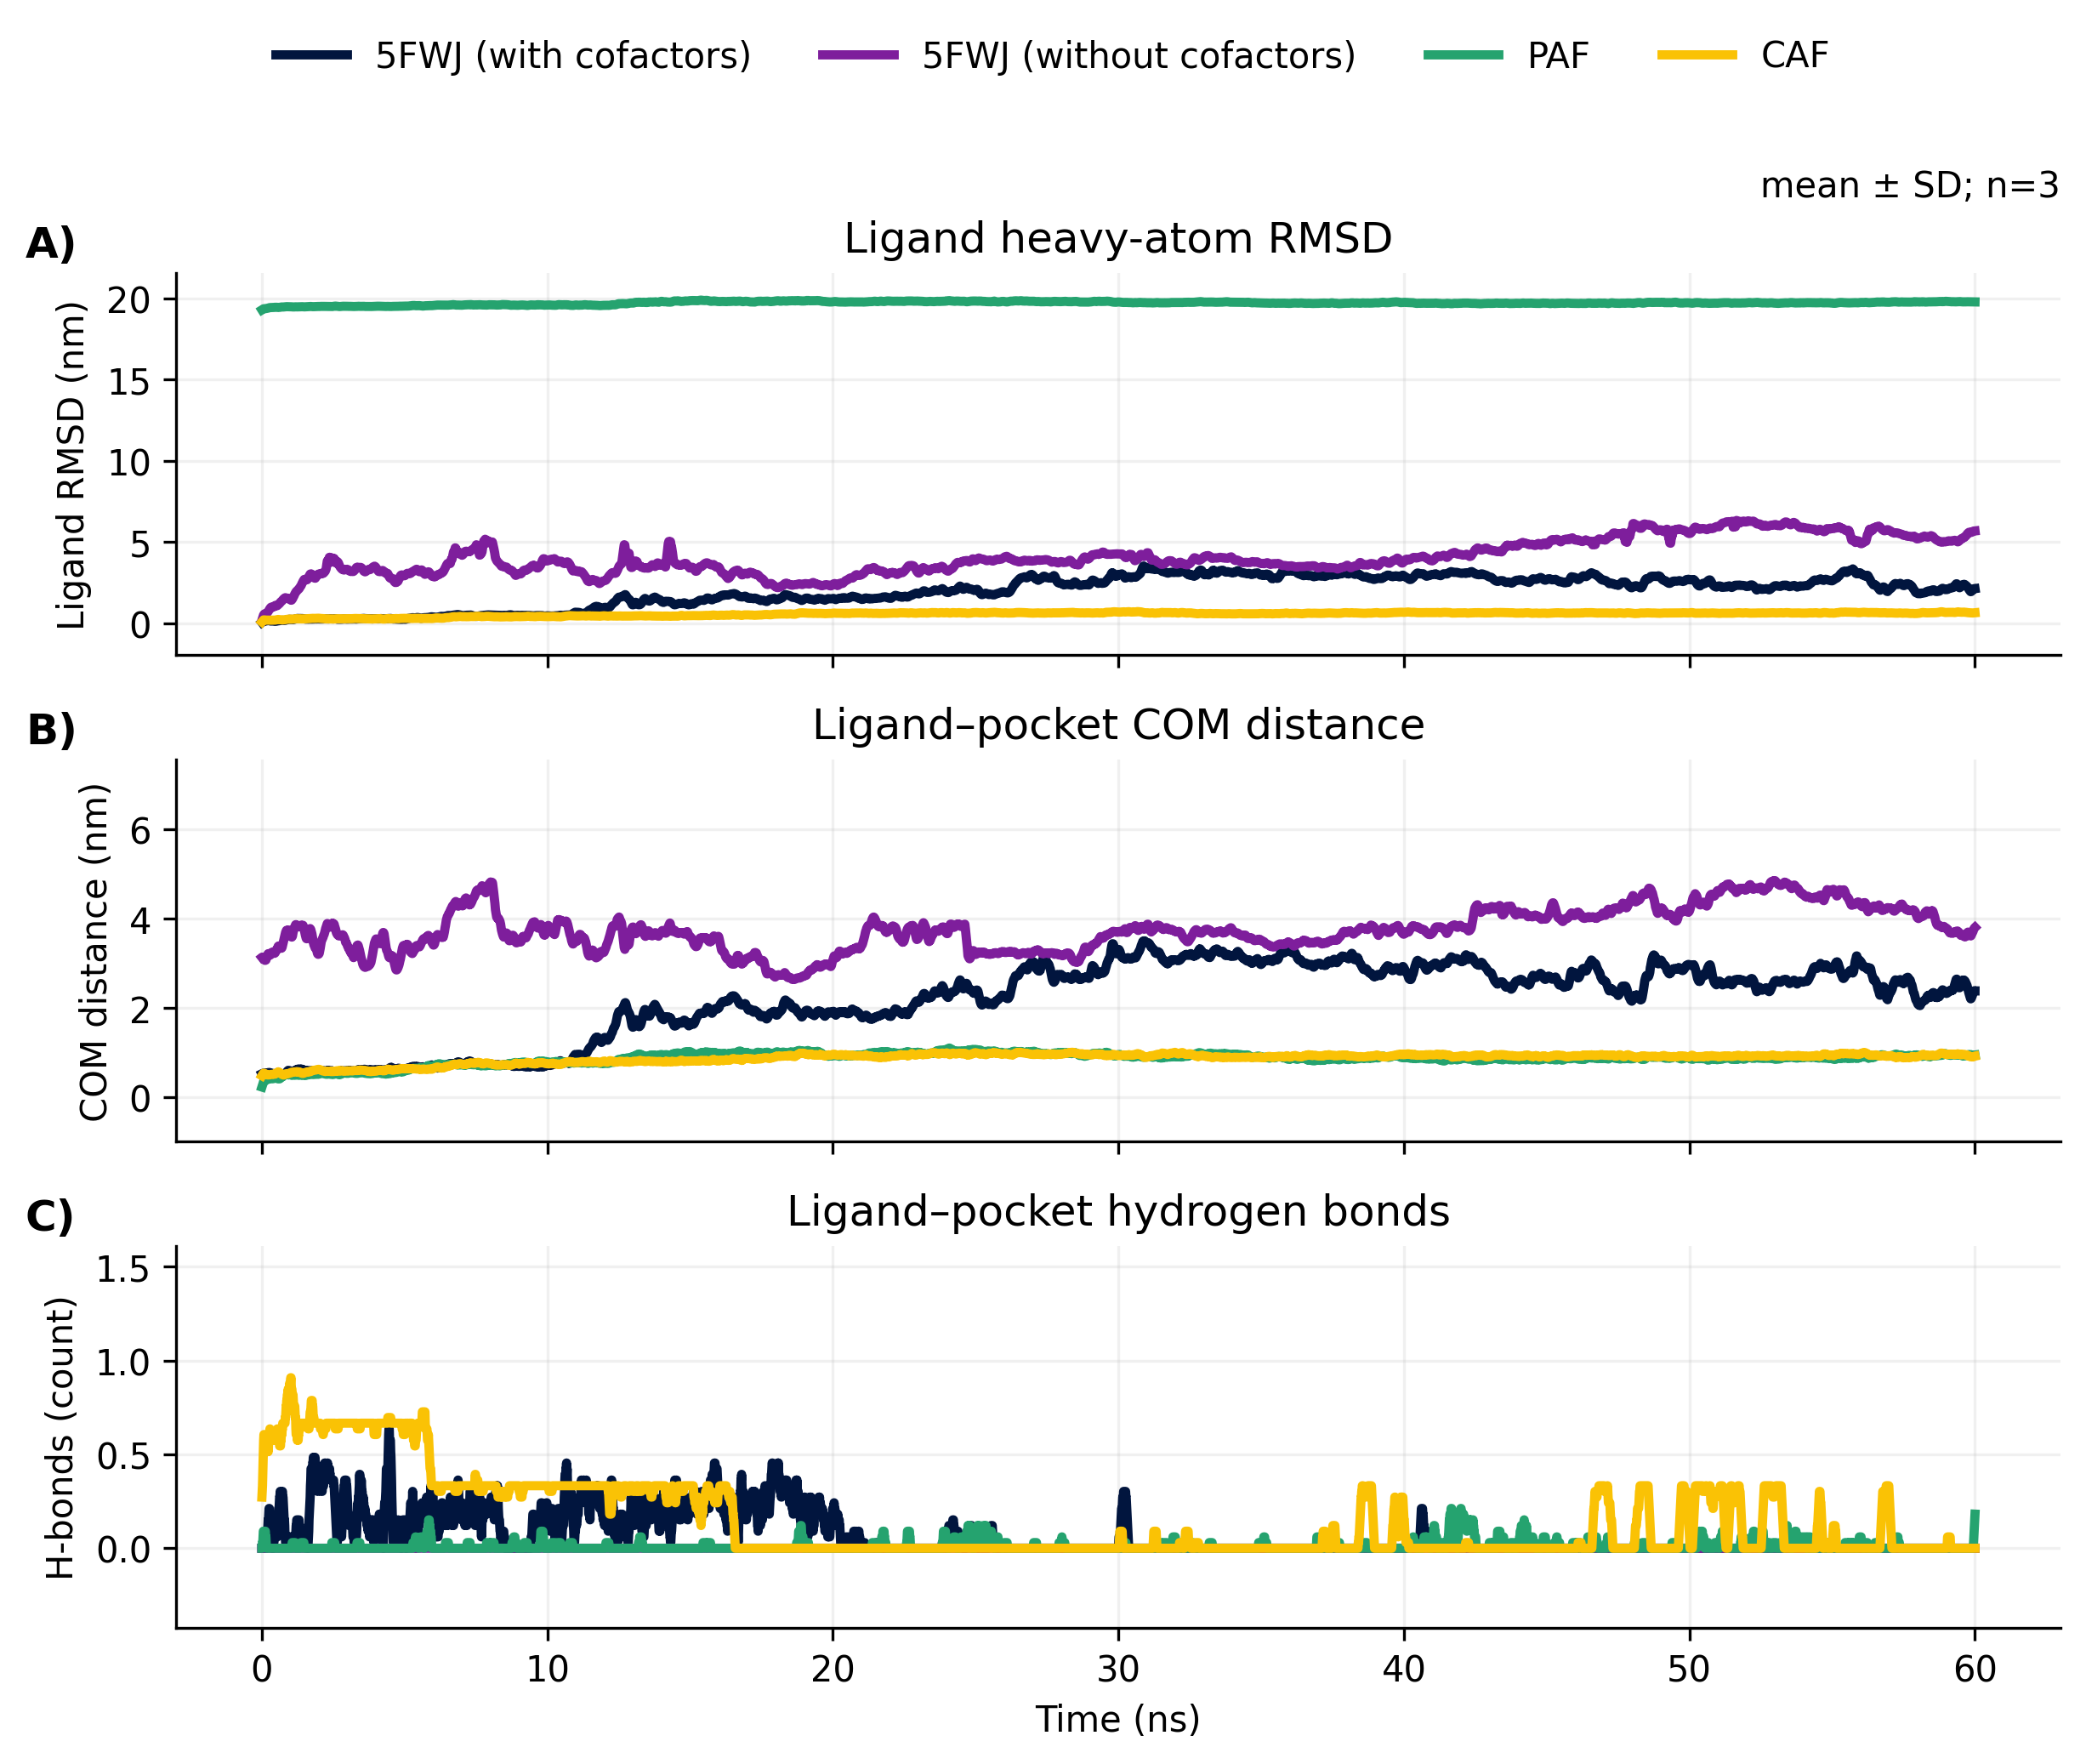

[OK] Saved: LigandSummary_ABC_meanSD.png and LigandSummary_ABC_meanSD.pdf


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("/content")

# Mapping filename tags -> display labels
TAG2LABEL = {
    "holo":"5FWJ (with cofactors)",
    "apo": "5FWJ (without cofactors)",
    "CAF":    "CAF",
    "PAF":  "PAF",
}

# xkcd palette (vivid, consistent with your style)
COL = {
    "5FWJ (with cofactors)"    : "xkcd:navy",
    "5FWJ (without cofactors)" : "xkcd:purple",
    "PAF"                      : "xkcd:teal green",
    "CAF"                      : "xkcd:goldenrod",
}

# which tags to try (script will auto-skip missing)
TAGS = ["holo", "apo", "PAF", "CAF"]

# file prefix patterns in your folder
METRICS = {
    "A": {"prefix": "ligand_rmsd_{tag}_rep",        "ylabel": "Ligand RMSD (nm)",         "title": "Ligand heavy-atom RMSD"},
    "B": {"prefix": "dist_COM_DOL_pocket_{tag}_rep", "ylabel": "COM distance (nm)",        "title": "Ligand–pocket COM distance"},
    "C": {"prefix": "hb_DOL_JmjC_{tag}_rep",         "ylabel": "H-bonds (count)",          "title": "Ligand–pocket hydrogen bonds"},
}

OUT_PNG = "LigandSummary_ABC_meanSD.png"
OUT_PDF = "LigandSummary_ABC_meanSD.pdf"

SMOOTH = True
SMOOTH_WINDOW = 11  # odd number (9–21 ok)

# ---------------- helpers ----------------
def read_xvg_2col(path):
    t, y = [], []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith(("@", "#")):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            try:
                t.append(float(parts[0]))
                y.append(float(parts[1]))
            except ValueError:
                continue
    return np.array(t), np.array(y)

def moving_average(y, w=11):
    if (w is None) or (w < 3):
        return y
    w = int(w)
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(w) / w
    return np.convolve(ypad, kernel, mode="valid")

def aggregate_reps(files):
    Ts, Ys = [], []
    for fp in files:
        t, y = read_xvg_2col(fp)
        Ts.append(t); Ys.append(y)

    common = set(Ts[0])
    for t in Ts[1:]:
        common = common.intersection(set(t))
    common = np.array(sorted(common))
    if len(common) == 0:
        raise ValueError("No common timepoints across replicas.")

    Y = []
    for t, y in zip(Ts, Ys):
        mp = {ti: yi for ti, yi in zip(t, y)}
        Y.append([mp[c] for c in common])
    Y = np.array(Y, dtype=float)   # (nrep, ntime)

    mu = Y.mean(axis=0)
    sd = Y.std(axis=0, ddof=1) if Y.shape[0] > 1 else np.zeros_like(mu)
    return common, mu, sd, Y.shape[0]

def style_axes(ax):
    ax.grid(True, which="major", alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def plot_mean_sd(ax, x, mu, sd, label, color, lw=2.6, band_alpha=0.18):
    ax.plot(x, mu, color=color, lw=lw, label=label)
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0, linewidth=0)

# ---------------- collect and plot ----------------
fig, axes = plt.subplots(3, 1, figsize=(8.2, 6.8), dpi=300, sharex=True)

all_handles = None
all_labels = None
n_used = []

for ax, panel in zip(axes, ["A", "B", "C"]):
    metric = METRICS[panel]

    for tag in TAGS:
        # find rep files
        pref = metric["prefix"].format(tag=tag)
        files = sorted(DATA_DIR.glob(f"{pref}*.xvg"))
        if len(files) == 0:
            continue

        t, mu, sd, nrep = aggregate_reps(files)
        n_used.append(nrep)

        if SMOOTH:
            mu = moving_average(mu, SMOOTH_WINDOW)
            sd = moving_average(sd, SMOOTH_WINDOW)

        label = TAG2LABEL.get(tag, tag)
        color = COL.get(label, "xkcd:black")
        plot_mean_sd(ax, t, mu, sd, label, color)

    ax.set_ylabel(metric["ylabel"])
    ax.set_title(metric["title"], pad=6)
    #ax.set_ylim(0, 8)   # or 10
    style_axes(ax)

    ax.text(-0.08, 1.02, f"{panel})", transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="bottom")

    if all_handles is None:
        all_handles, all_labels = ax.get_legend_handles_labels()

axes[-1].set_xlabel("Time (ns)")

# top legend
if all_handles and all_labels:
    fig.legend(all_handles, all_labels, loc="upper center", ncol=4,
               frameon=False, bbox_to_anchor=(0.5, 1.02))

n_auto = min(n_used) if len(n_used) else None
if n_auto is not None:
    # optional small note (kept subtle)
    axes[0].text(1.0, 1.18, f"mean ± SD; n={n_auto}",
                 transform=axes[0].transAxes, ha="right", va="bottom", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print("[OK] Saved:", OUT_PNG, "and", OUT_PDF)

#**Metal coordination analysis**

#1) Summary of Stability Metrics

In [5]:
import glob, os, re, math
import pandas as pd

# =========================
# SETTINGS
# =========================
XVG_GLOB = "**/*.xvg"
USE_TIME_WINDOW = True
T0 = 20.0
T1 = 60.0
TIME_UNIT = "ns"   # change to "ps" if your XVG time column is in ps

# =========================
# COLLECT FILES
# =========================
ALL_XVG = glob.glob(XVG_GLOB, recursive=True)

# Expected filenames:
# dist_MN_GLU516_OE2_rep1.xvg
# contact_MN_HIS514_NE2_rep2.xvg
dist_pat = re.compile(r"^dist_MN_(.+)_(rep\d+)\.xvg$")
contact_pat = re.compile(r"^contact_MN_(.+)_(rep\d+)\.xvg$")

dist_files = {}
contact_files = {}

for p in ALL_XVG:
    b = os.path.basename(p)

    m = dist_pat.match(b)
    if m:
        pair, rep = m.group(1), m.group(2)
        dist_files[(rep, pair)] = p
        continue

    m = contact_pat.match(b)
    if m:
        pair, rep = m.group(1), m.group(2)
        contact_files[(rep, pair)] = p

# =========================
# HELPERS
# =========================
def convert_time_to_ns(t, unit="ns"):
    if unit.lower() == "ps":
        return t / 1000.0
    return t

def read_xvg_xy(path):
    x, y = [], []
    with open(path) as f:
        for line in f:
            if line.startswith(("#", "@")) or not line.strip():
                continue
            parts = line.split()
            if len(parts) >= 2:
                x.append(float(parts[0]))
                y.append(float(parts[1]))
    return x, y

def filter_time_window(x, y, t0=20.0, t1=60.0, time_unit="ns"):
    y_filtered = []
    for xx, yy in zip(x, y):
        xx_ns = convert_time_to_ns(xx, time_unit)
        if t0 <= xx_ns <= t1:
            y_filtered.append(yy)
    return y_filtered

def mean_sd_min(y):
    n = len(y)
    if n == 0:
        return None, None, None
    mean = sum(y) / n
    var = sum((v - mean) ** 2 for v in y) / (n - 1) if n > 1 else 0.0
    sd = math.sqrt(var)
    return mean, sd, min(y)

def nm_to_angstrom(v):
    return v * 10.0 if v is not None else None

def format_pair(pair_raw):
    # GLU516_OE2 -> Mn–Glu516 OE2
    parts = pair_raw.split("_")
    if len(parts) == 2:
        residue, atom = parts
        residue_fmt = residue[:3].capitalize() + residue[3:]
        return f"Mn–{residue_fmt} {atom}"
    return f"Mn–{pair_raw}"

# =========================
# BUILD PER-REPLICA TABLE
# =========================
keys = sorted(set(dist_files.keys()) | set(contact_files.keys()))

rows = []
for (rep, pair_raw) in keys:
    dfile = dist_files.get((rep, pair_raw), "")
    cfile = contact_files.get((rep, pair_raw), "")

    mean_dist_A = sd_dist_A = min_dist_A = occ = None
    n_dist_points = n_contact_points = 0

    if dfile:
        x, y = read_xvg_xy(dfile)
        y_use = filter_time_window(x, y, T0, T1, TIME_UNIT) if USE_TIME_WINDOW else y
        n_dist_points = len(y_use)

        md_nm, sd_nm, mind_nm = mean_sd_min(y_use)
        mean_dist_A = nm_to_angstrom(md_nm)
        sd_dist_A = nm_to_angstrom(sd_nm)
        min_dist_A = nm_to_angstrom(mind_nm)

    if cfile:
        x, y = read_xvg_xy(cfile)
        y_use = filter_time_window(x, y, T0, T1, TIME_UNIT) if USE_TIME_WINDOW else y
        n_contact_points = len(y_use)
        occ = (sum(y_use) / len(y_use)) * 100 if y_use else None

    rows.append({
        "replica": rep,
        "pair_raw": pair_raw,
        "pair": format_pair(pair_raw),
        "mean_dist_A": mean_dist_A,
        "sd_dist_A": sd_dist_A,
        "min_dist_A": min_dist_A,
        "occupancy_%": occ,
        "n_dist_points": n_dist_points,
        "n_contact_points": n_contact_points,
        "dist_file": dfile,
        "contact_file": cfile,
    })

replica_df = pd.DataFrame(rows)

for col in ["mean_dist_A", "sd_dist_A", "min_dist_A", "occupancy_%"]:
    replica_df[col] = replica_df[col].round(4)

replica_df = replica_df.sort_values(["pair_raw", "replica"]).reset_index(drop=True)
replica_df.to_csv("metal_contact_replica_summary_angstrom.csv", index=False)

print("Saved: metal_contact_replica_summary_angstrom.csv")
print(replica_df)

# =========================
# BUILD ACROSS-REPLICA TABLE
# =========================
summary_df = (
    replica_df.groupby(["pair_raw", "pair"], as_index=False)
    .agg(
        mean_dist_A_mean=("mean_dist_A", "mean"),
        mean_dist_A_sd=("mean_dist_A", "std"),
        sd_dist_A_mean=("sd_dist_A", "mean"),
        min_dist_A_mean=("min_dist_A", "mean"),
        min_dist_A_min=("min_dist_A", "min"),
        occupancy_mean=("occupancy_%", "mean"),
        occupancy_sd=("occupancy_%", "std"),
        n_replicas=("replica", "count"),
    )
)

for col in [
    "mean_dist_A_mean",
    "mean_dist_A_sd",
    "sd_dist_A_mean",
    "min_dist_A_mean",
    "min_dist_A_min",
    "occupancy_mean",
    "occupancy_sd",
]:
    summary_df[col] = summary_df[col].round(4)

summary_df = summary_df.sort_values("pair_raw").reset_index(drop=True)
summary_df.to_csv("metal_contact_across_replicas_summary_angstrom.csv", index=False)

print("\nSaved: metal_contact_across_replicas_summary_angstrom.csv")
print(summary_df)

Saved: metal_contact_replica_summary_angstrom.csv
  replica    pair_raw           pair  mean_dist_A  sd_dist_A  min_dist_A  \
0    rep1  GLU516_OE2  Mn–Glu516 OE2       2.2385     0.3518      1.9308   
1    rep2  GLU516_OE2  Mn–Glu516 OE2       2.2776     0.4572      1.9031   
2    rep3  GLU516_OE2  Mn–Glu516 OE2       2.0016     0.0407      1.8756   
3    rep1  HIS514_NE2  Mn–His514 NE2       7.4997     0.9196      4.5170   
4    rep2  HIS514_NE2  Mn–His514 NE2       6.8172     1.3810      4.2913   
5    rep3  HIS514_NE2  Mn–His514 NE2       7.5339     1.3448      4.3196   
6    rep1  HIS602_NE2  Mn–His602 NE2       5.3152     2.5242      2.1156   
7    rep2  HIS602_NE2  Mn–His602 NE2       3.5315     1.0749      2.0716   
8    rep3  HIS602_NE2  Mn–His602 NE2       2.2532     0.0635      2.0766   

   occupancy_%  n_dist_points  n_contact_points                    dist_file  \
0      92.0770           4001              4001  dist_MN_GLU516_OE2_rep1.xvg   
1      89.3027           4001

#2) Time-series plots

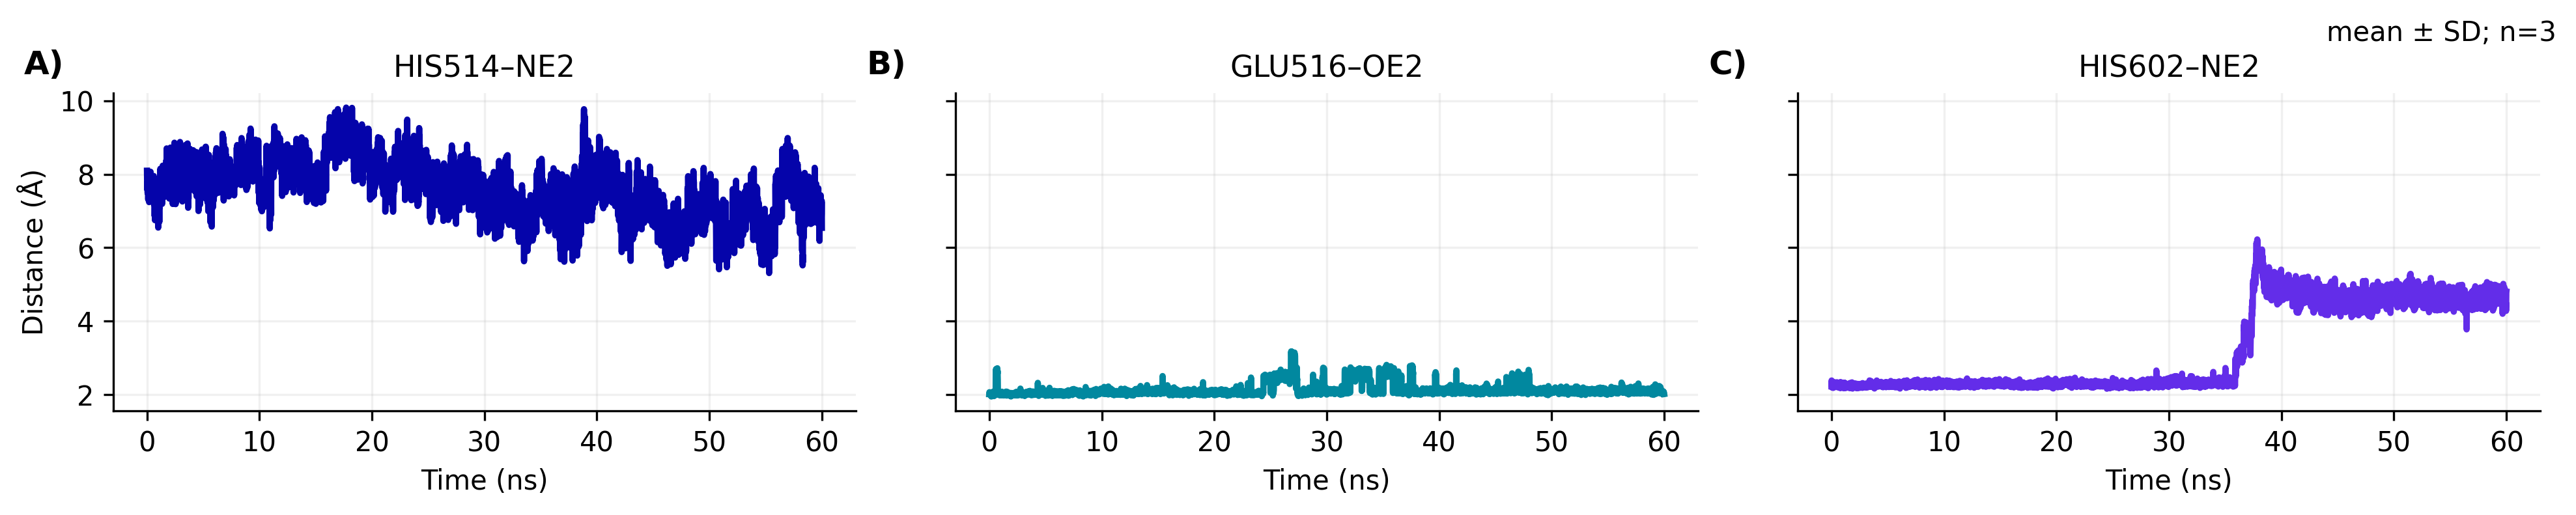

[OK] Saved: Mn_coordination_holo_xkcd_horizontal.png and Mn_coordination_holo_xkcd_horizontal.pdf


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# SETTINGS
# =========================
DATA_DIR = Path("/content")
OUT_PNG  = "Mn_coordination_holo_xkcd_horizontal.png"
OUT_PDF  = "Mn_coordination_holo_xkcd_horizontal.pdf"

# xkcd palette (panel-specific, vivid but still coherent)
PANEL_COL = {
    "HIS514–NE2": "xkcd:royal blue",
    "GLU516–OE2": "xkcd:teal blue",
    "HIS602–NE2": "xkcd:purple blue",
}

# patterns (your current filenames)
DATASETS = [
    ("HIS514–NE2", "dist_MN_HIS514_NE2_rep*.xvg"),
    ("GLU516–OE2", "dist_MN_GLU516_OE2_rep*.xvg"),
    ("HIS602–NE2", "dist_MN_HIS602_NE2_rep*.xvg"),
]

# style knobs
BAND_ALPHA = 0        # SD shadow strength (0 = no band)
LINE_W     = 2.3
DPI        = 300
FIGSIZE    = (13.2, 2.6)   # <-- wide horizontal layout

# =========================
# HELPERS
# =========================
def read_xvg(path):
    """Read a 2-column XVG (time, value), skipping @/# metadata."""
    t, y = [], []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not line or line.startswith(("@", "#")):
                continue
            s = line.split()
            if len(s) >= 2:
                try:
                    t.append(float(s[0]))
                    y.append(float(s[1]))
                except ValueError:
                    continue
    return np.array(t), np.array(y)

def style_axes(ax):
    ax.grid(True, alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def collect_replicas(pattern):
    """Stack replicas matching pattern; return (t_common, mean, sd, nrep)."""
    files = sorted(DATA_DIR.glob(pattern))
    if len(files) == 0:
        raise FileNotFoundError(f"No files matched: {pattern}")

    Ts, Ys = [], []
    for fp in files:
        t, y = read_xvg(fp)
        Ts.append(t)
        Ys.append(y)

    # intersection of time points (robust)
    common = set(Ts[0])
    for t in Ts[1:]:
        common = common.intersection(set(t))
    common = np.array(sorted(common))
    if len(common) == 0:
        raise ValueError(f"No common timepoints across replicas for pattern: {pattern}")

    Y = []
    for t, y in zip(Ts, Ys):
        mp = {ti: yi for ti, yi in zip(t, y)}
        Y.append([mp[c] for c in common])
    Y = np.array(Y, dtype=float)  # (nrep, ntime)

    mean = Y.mean(axis=0)
    sd   = Y.std(axis=0, ddof=1) if Y.shape[0] > 1 else np.zeros_like(mean)
    return common, mean, sd, Y.shape[0]

def plot_panel(ax, t, mean, sd, title, color):
    """Plot mean ± SD; convert nm -> Å for display."""
    mean_A = mean * 10.0
    sd_A   = sd * 10.0

    ax.plot(t, mean_A, lw=LINE_W, color=color)
    if BAND_ALPHA and BAND_ALPHA > 0:
        ax.fill_between(t, mean_A - sd_A, mean_A + sd_A, color=color, alpha=BAND_ALPHA, linewidth=0)

    ax.set_title(title, fontsize=11)
    style_axes(ax)

# =========================
# PLOT (HORIZONTAL: 1 row × 3 cols)
# =========================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, sharex=True, sharey=True, dpi=DPI)

nrep_used = []
for ax, (title, pat) in zip(axes, DATASETS):
    t, mean, sd, nrep = collect_replicas(pat)
    nrep_used.append(nrep)
    plot_panel(ax, t, mean, sd, title, PANEL_COL.get(title, "xkcd:navy"))

# shared labels
axes[0].set_ylabel("Distance (Å)")
for ax in axes:
    ax.set_xlabel("Time (ns)")

# panel labels A) B) C)
for i, ax in enumerate(axes):
    ax.text(-0.12, 1.04, f"{chr(65+i)})",
            transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="bottom")

# small note on the right/top
if nrep_used:
    fig.text(0.995, 0.995, f"mean ± SD; n={min(nrep_used)}",
             ha="right", va="top", fontsize=10)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print("[OK] Saved:", OUT_PNG, "and", OUT_PDF)